# Trabajo Práctico 2

## Modelo predictivo de lluvia en Australia

### Facultad de Ciencias Exactas, Ingenieria y Agrimensura (FCEIA) - Universidad Nacional de Rosario (UNR)

**Integrantes:**
| Nombre | Legajo |
|----------|-------|
| Chiappe, Maximiliano | C-7542/6 |
| Lenarduzzi, Juan | L-3398/7 |
---



## Configuración del Entorno

In [1]:
# ── Librerías generales ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn: preprocesamiento ───────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer

# ── Scikit-learn: regresión logística ────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

---

## Carga e Inspección del Dataset

In [2]:
df = pd.read_csv('weatherAUS_2026C1.csv')

print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Memoria utilizada: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB') # Esto les va a servir cuando tengan un dataset muy pesado :)
print()
df.head(5)

Dimensiones del dataset: 145412 filas x 25 columnas
Memoria utilizada: 82.42 MB



,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        145412 non-null  int64  
 1   Date              145412 non-null  object 
 2   Location          145412 non-null  object 
 3   MinTemp           143928 non-null  float64
 4   MaxTemp           144159 non-null  float64
 5   Rainfall          142152 non-null  float64
 6   Evaporation       82658 non-null   float64
 7   Sunshine          75616 non-null   float64
 8   WindGustDir       135096 non-null  object 
 9   WindGustSpeed     135159 non-null  float64
 10  WindDir9am        134850 non-null  object 
 11  WindDir3pm        141186 non-null  object 
 12  WindSpeed9am      143645 non-null  float64
 13  WindSpeed3pm      142351 non-null  float64
 14  Humidity9am       142759 non-null  float64
 15  Humidity3pm       140907 non-null  float64
 16  Pressure9am       13

---
## Análisis Descriptivo

---
### Limpieza Global

In [4]:
df_limpio = df.copy()

---
#### Registros Duplicados

In [5]:
df_limpio.duplicated().sum()

0

---
#### NaN´s en la Variable Objetivo

In [6]:
df_limpio['RainTomorrow'].value_counts()

RainTomorrow
No     110281
Yes     31872
Name: count, dtype: int64

In [7]:
df_limpio['RainTomorrow'].isna().sum()

3259

In [8]:
df_limpio = df_limpio.dropna(subset=['RainTomorrow'])
print(df_limpio.shape)

(142153, 25)


Se decide eliminar los Nulos de la columna RainTomorrow ya que representan un 2,2% del total de registros, y se trata de la variable objetivo.

---
#### Columnas

In [9]:
df_limpio['Date'] = pd.to_datetime(df_limpio['Date'])

df_limpio['Month'] = df_limpio['Date'].dt.month
df_limpio['Month'].value_counts()

Month
5     13055
3     13036
1     12921
6     12349
10    11804
7     11779
8     11762
11    11461
9     11345
4     11306
12    10810
2     10525
Name: count, dtype: int64

In [10]:
df_limpio = df_limpio.drop(columns = ['Unnamed: 0', 'Date', 'RainfallTomorrow'])

In [11]:
df_limpio.head(4)

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Month
0,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,W,WNW,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,12
1,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,NNW,WSW,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,12
2,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,W,WSW,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,12
3,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,SE,E,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,12


Se extrae el mes de la fecha para utilizarlo luego en el modelo. Se elimina la Columna 'Unnamed: 0' que solo contenía índices. Se elimina la columna 'RainfallTomorrow' ya que da información al modelo sobre la respuesta que deberá predecir (evitar fuga de datos).

---
### División Train-Test

In [12]:
# Separamos X (features) e y (target)
X = df_limpio.drop(columns=['RainTomorrow'])
y = df_limpio['RainTomorrow']

# Hacemos el corte (80% train, 20% test)
# El stratify=y mantiene la misma proporción de días con lluvia y sin lluvia en ambos lados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (113722, 22), y_train: (113722,)
X_test: (28431, 22), y_test: (28431,)


---
### Visualización de Variables

In [13]:
df_train = X_train.copy()
df_train['RainTomorrow'] = y_train
df_train.shape

(113722, 23)

In [14]:
df_train.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,Month
count,113210.000000,113470.000000,112582.000000,65008.000000,59396.000000,106328.000000,112641.000000,111587.000000,112295.000000,110806.000000,102431.000000,102448.000000,70833.000000,68023.000000,112995.000000,111516.000000,113722.000000
mean,12.174022,23.212820,2.362902,5.466721,7.617550,39.963547,14.018057,18.631023,68.854287,51.506860,1017.672497,1015.274660,4.439386,4.505505,16.974848,21.669933,6.403871
std,6.426738,7.131541,8.588292,4.209742,3.785206,13.628109,8.908431,8.848357,19.099642,20.841426,7.105716,7.038943,2.888114,2.720124,6.515268,6.953483,3.422053
min,-9.700000,-5.100000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.300000,977.400000,0.000000,0.000000,-8.000000,-5.800000,1.000000
25%,7.600000,17.900000,0.000000,2.600000,4.900000,31.000000,7.000000,12.000000,56.900000,36.600000,1013.000000,1010.500000,1.000000,2.000000,12.200000,16.600000,3.000000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,38.000000,13.000000,18.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,6.000000
75%,16.800000,28.200000,0.600000,7.400000,10.600000,47.000000,19.000000,24.000000,83.100000,65.700000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,9.000000
max,34.100000,49.100000,371.000000,145.000000,14.500000,135.000000,88.000000,82.000000,100.000000,100.000000,1041.200000,1039.800000,9.000000,8.000000,39.800000,47.000000,12.000000


---
#### Variables numéricas

In [15]:
cols_num = ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed',
            'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am',
            'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

cols_cat = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
    'RainToday', 'Month']

target = ['RainTomorrow']

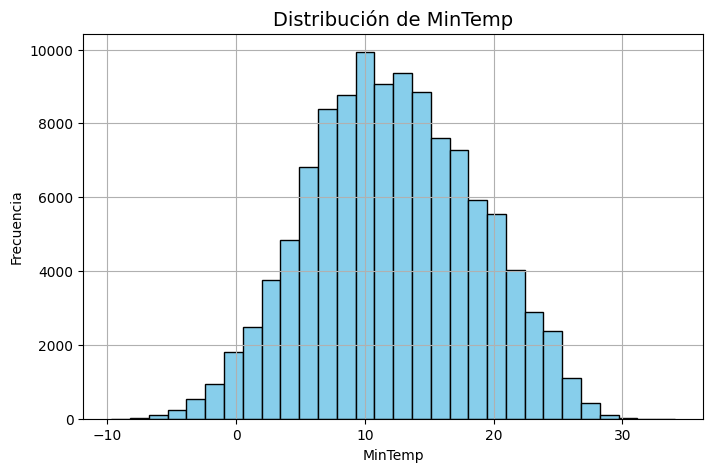

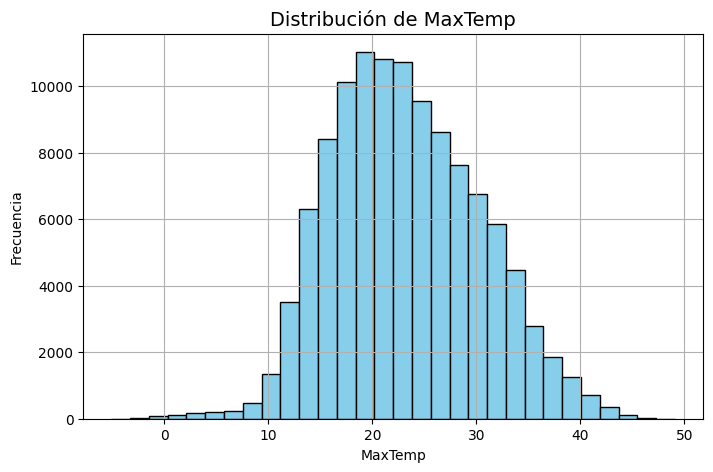

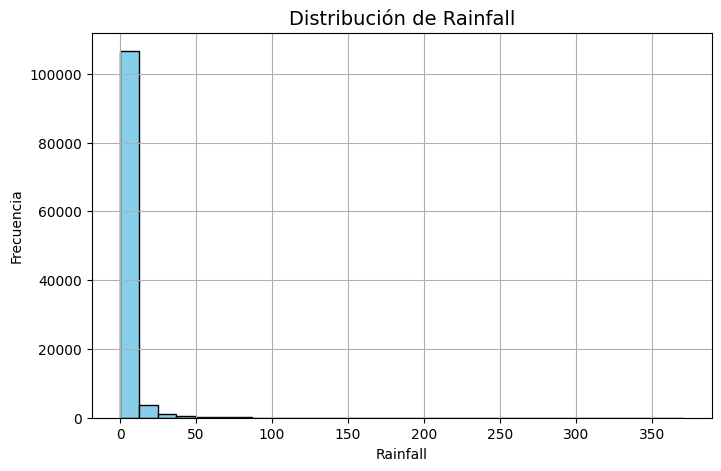

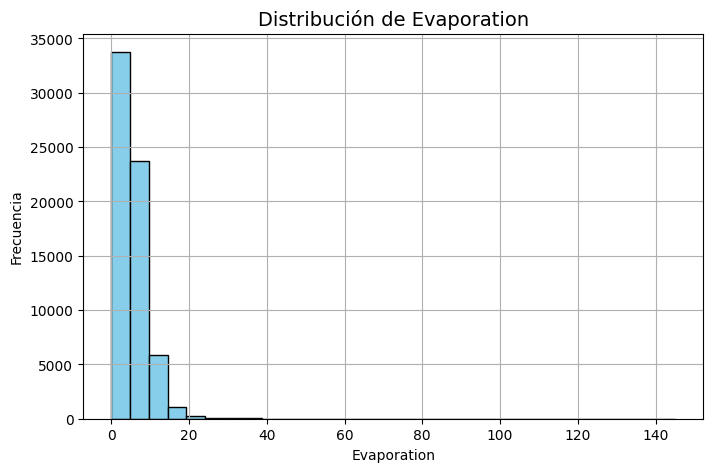

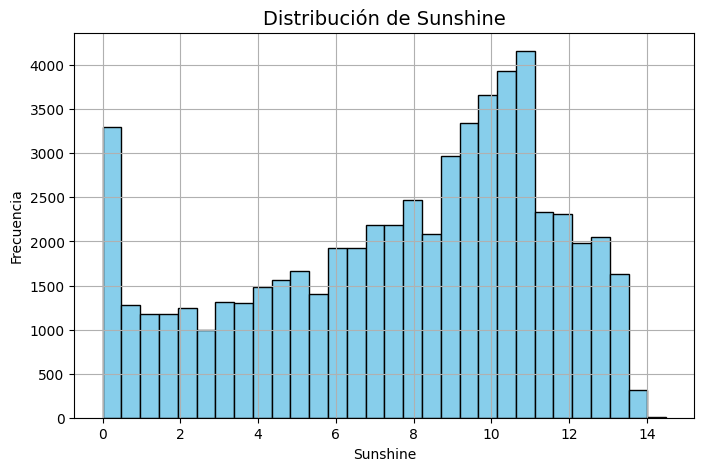

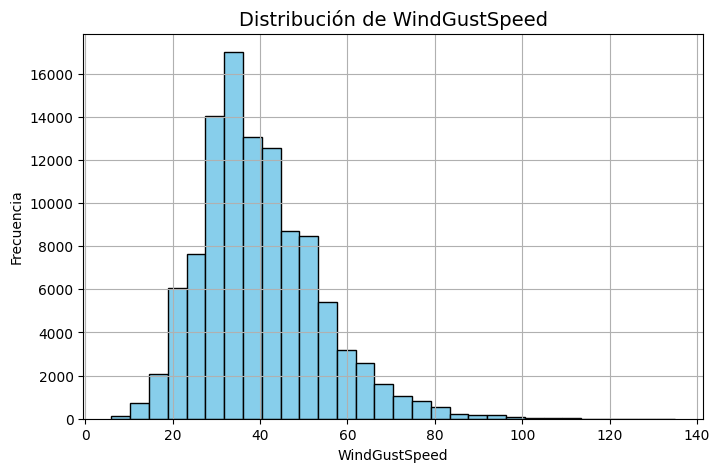

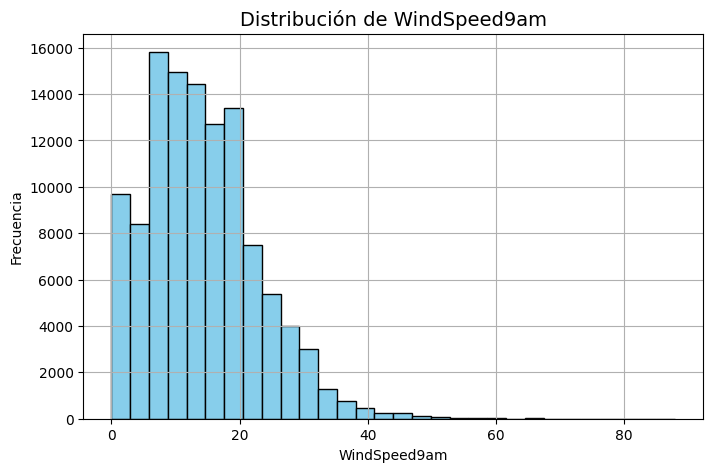

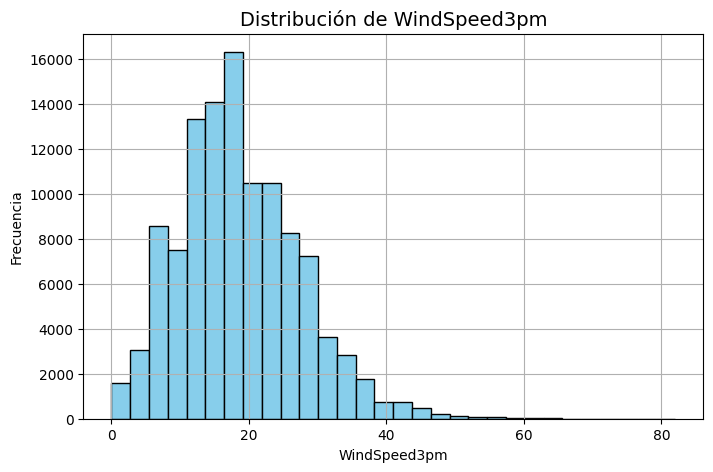

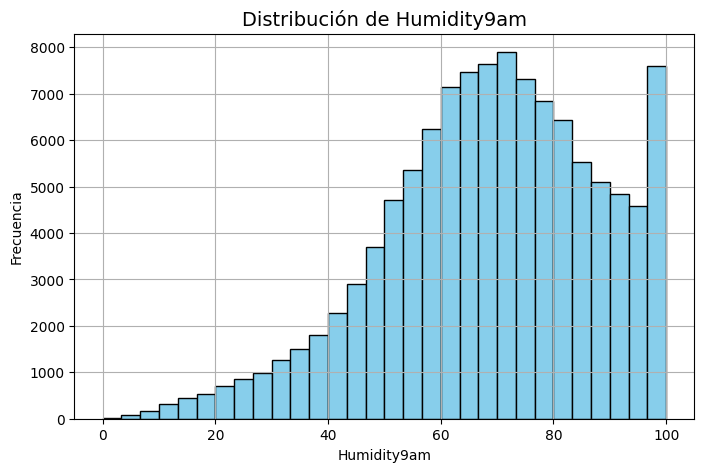

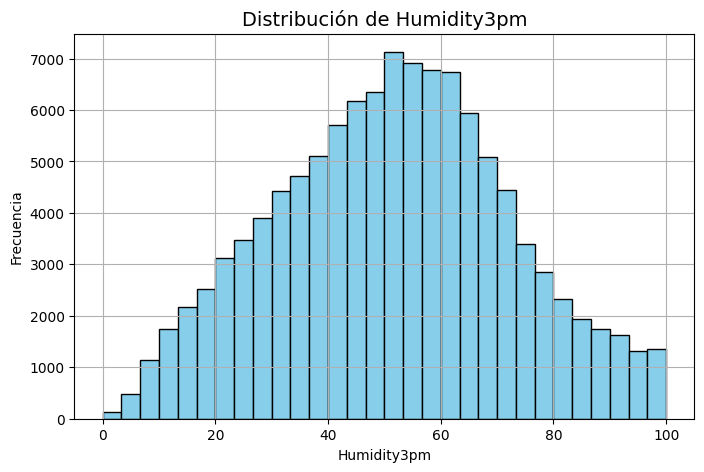

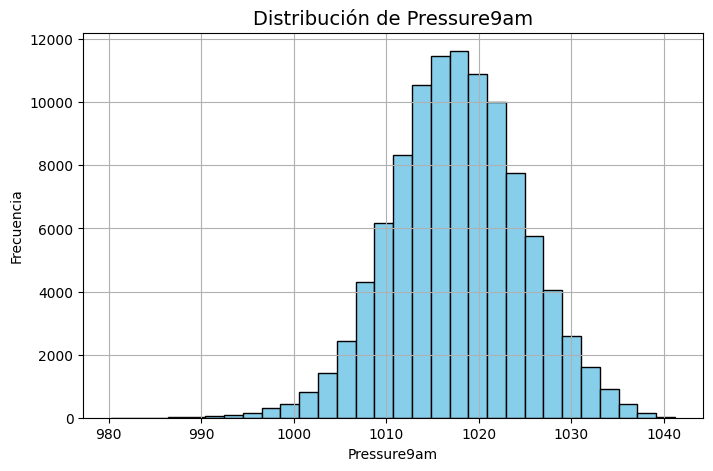

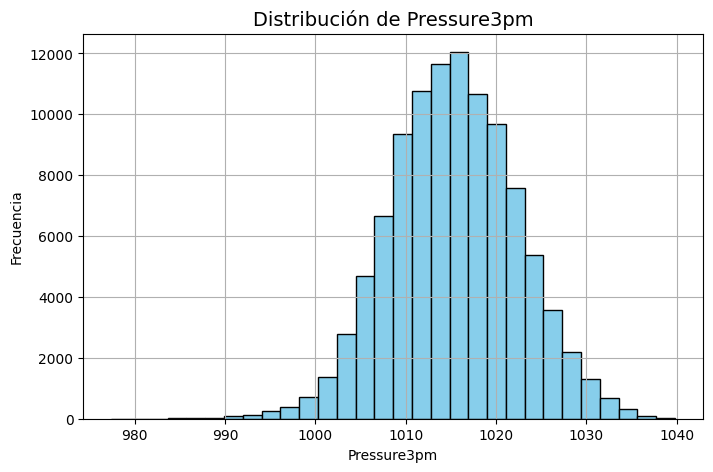

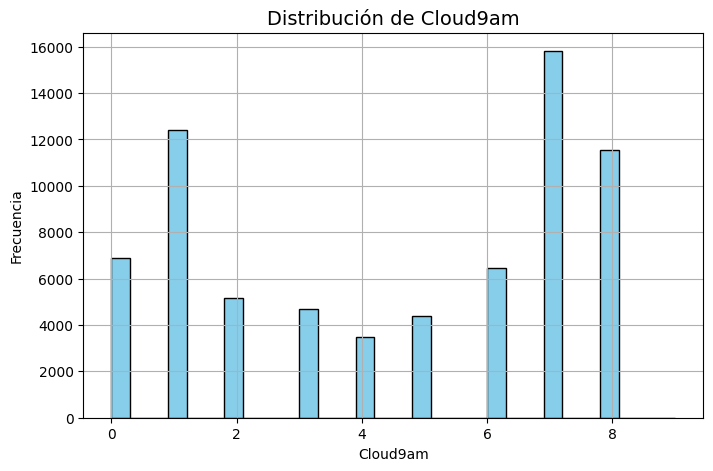

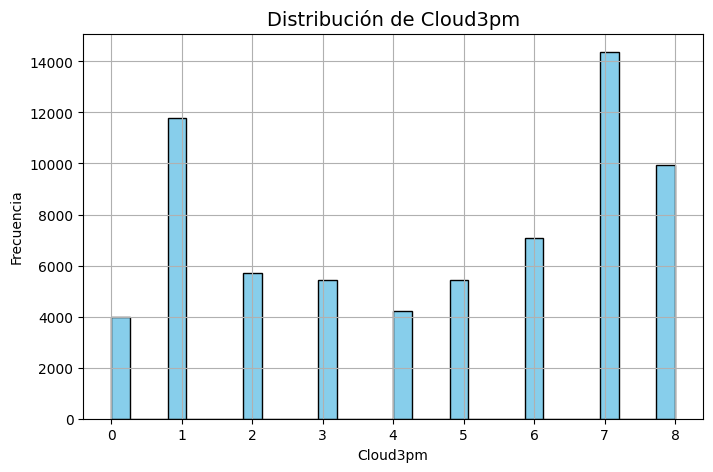

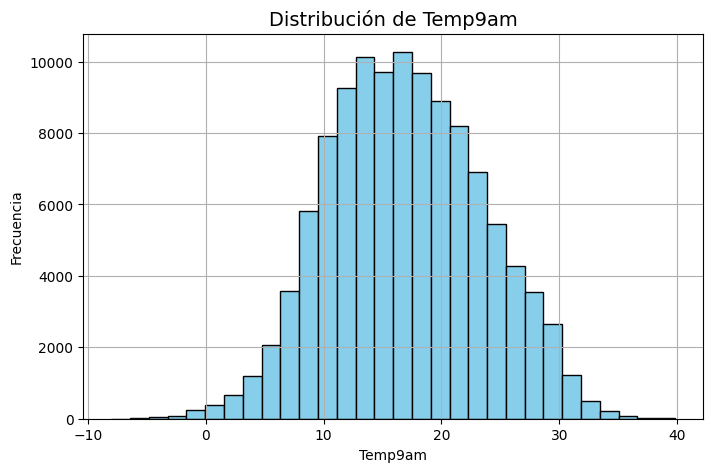

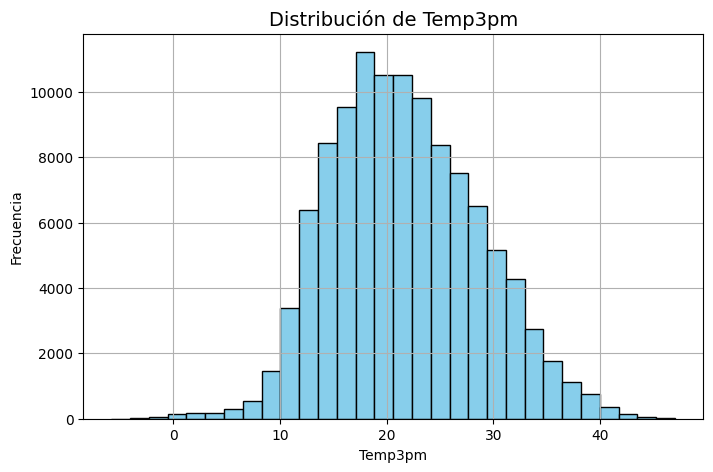

In [16]:
# Hacemos un for para graficar variable por variable
for col in cols_num:
    plt.figure(figsize=(8, 5))
    X_train[col].hist(bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Distribución de {col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

En las distribuciones de las variables numéricas se observan distribuciones simétricas en la mayoría de los casos, excepto en las variables 'Rainfall' y 'Evaporation', donde se ve una asimetría hacia la derecha.

---
#### Variables Categóricas

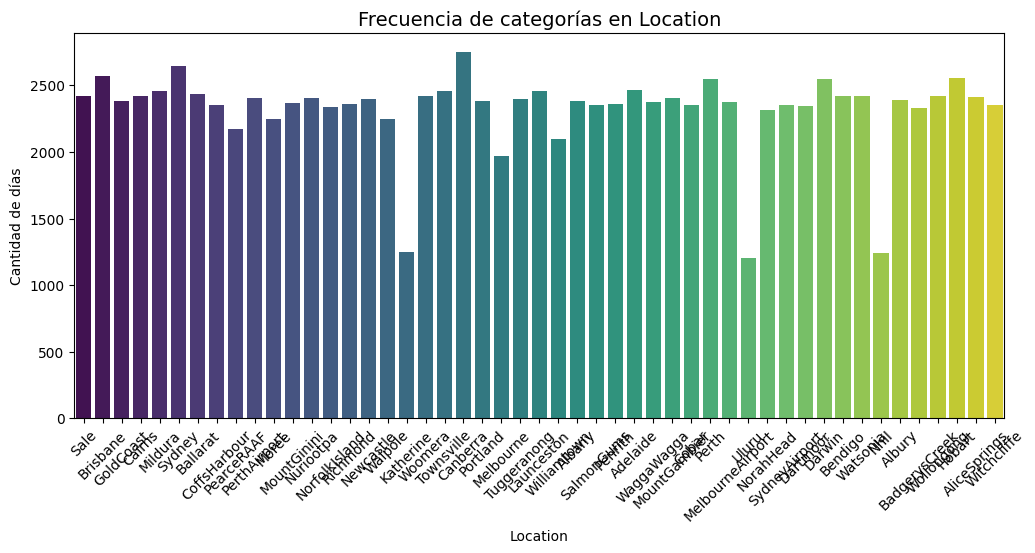

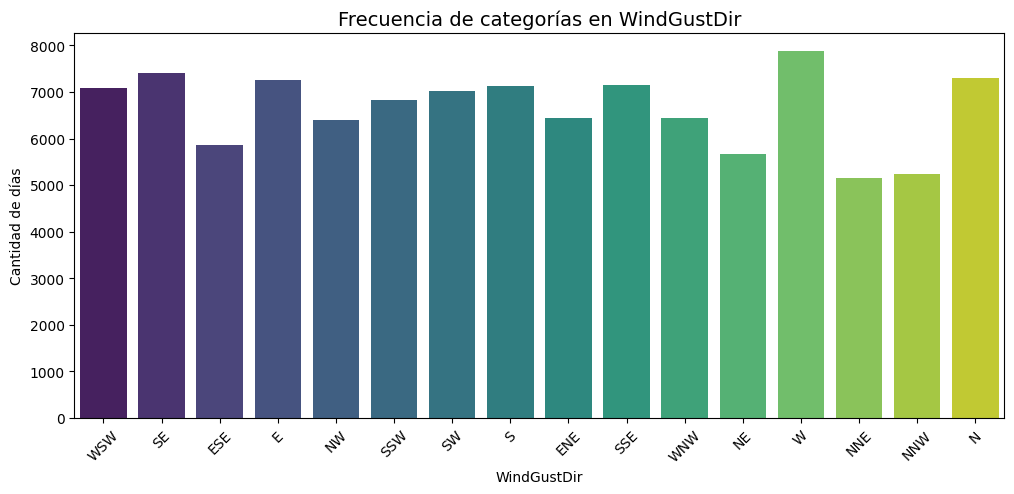

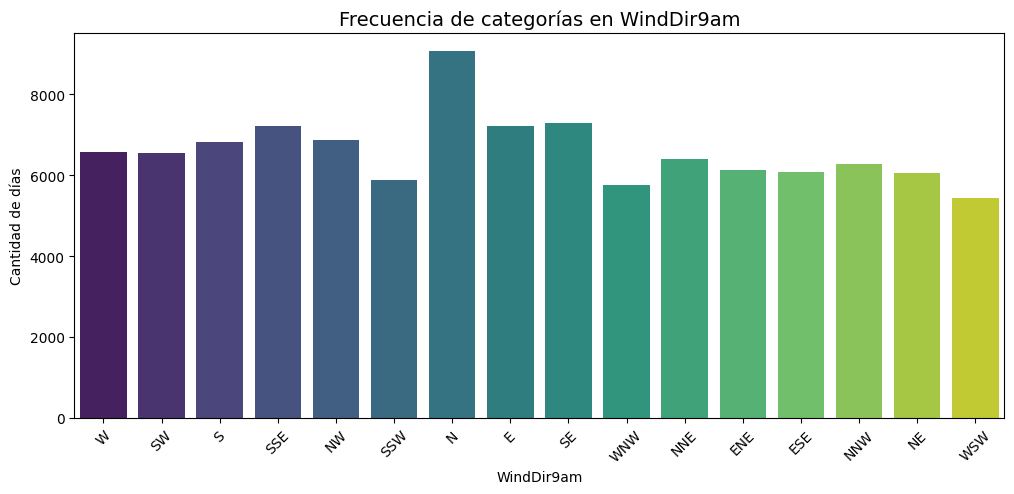

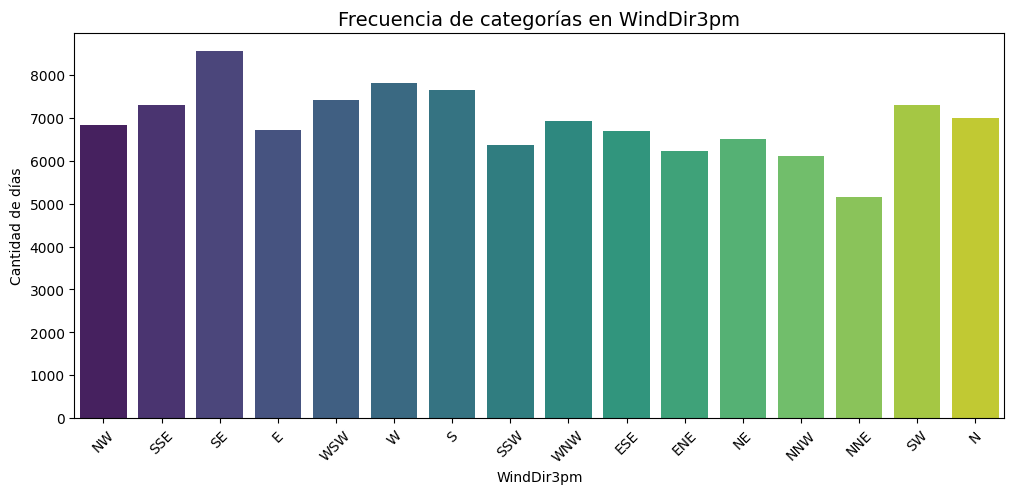

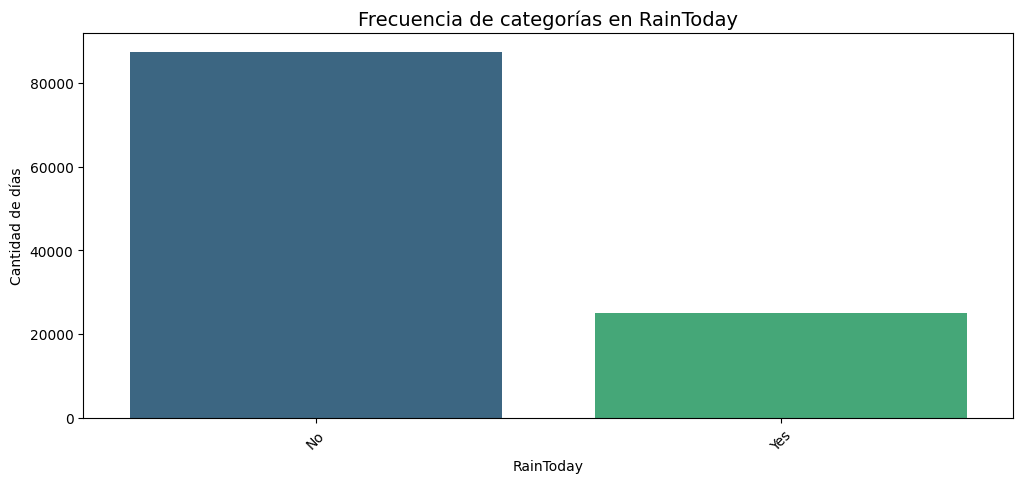

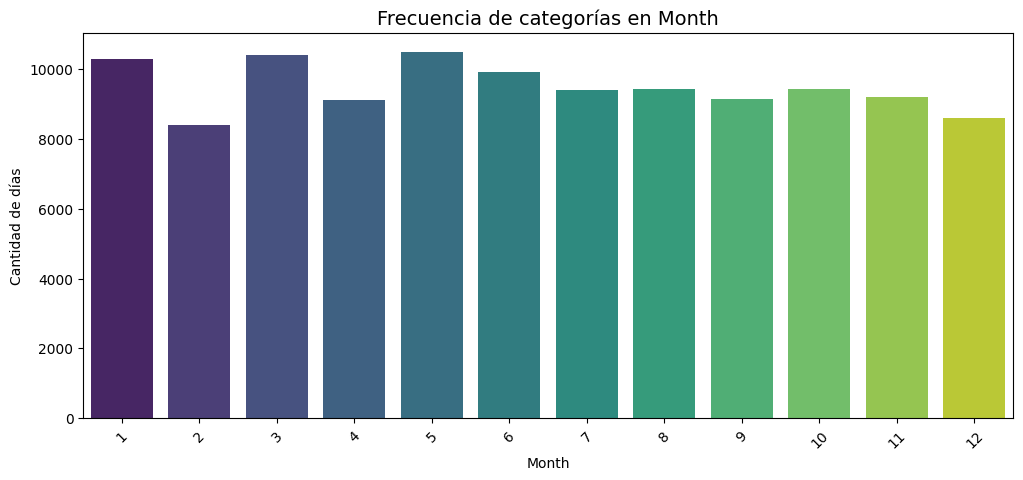

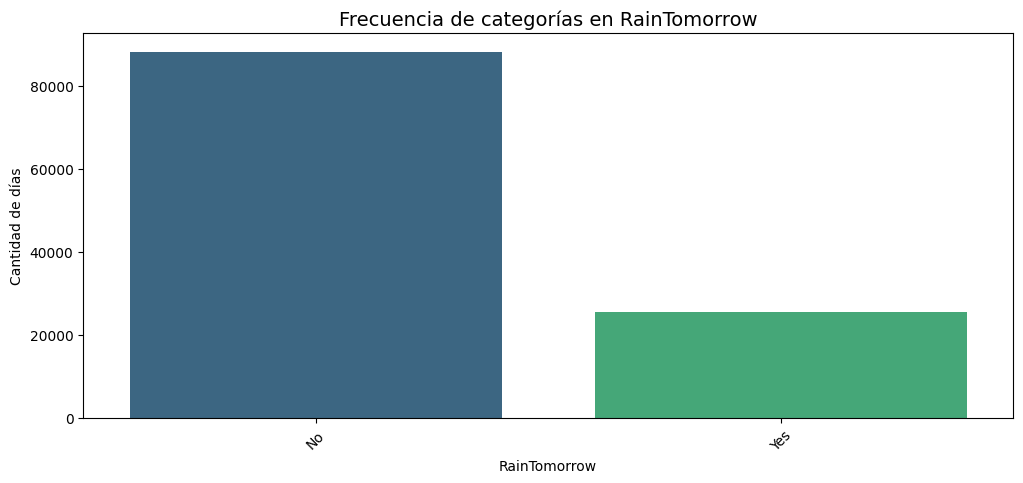

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

cols_cat_target = cols_cat + target

# 2. Hacemos un for para graficar barras
for col in cols_cat_target:
    plt.figure(figsize=(12, 5))
    sns.countplot(data=df_train, x=col, palette='viridis')
    plt.title(f'Frecuencia de categorías en {col}', fontsize=14)
    plt.xticks(rotation=45)
    plt.ylabel('Cantidad de días')
    plt.show()

Se observa que variables como Location o WindDir tienen alta cardinalidad. Al observar la distribución de RainTomorrow se concluye que el dataset está fuertemente desbalanceado. Creemos que es importante saber esto ya que el desbalanceo afecta al modelo y en caso de estarlo probablemente se deba hacer un paso extra para balancear las clases.

---
### Limpieza el Dataset

---
#### Imputación

In [18]:
# Para los números usamos la mediana (menos sensible a outliers)
imputer_num = SimpleImputer(strategy='median')
# Para los textos usamos la moda (el valor que más se repite)
imputer_cat = SimpleImputer(strategy='most_frequent')

# Fit_transform: aprende la mediana del train y rellena el train
X_train[cols_num] = imputer_num.fit_transform(X_train[cols_num])
# Transform: rellena el test con la misma mediana que aprendió del train
X_test[cols_num] = imputer_num.transform(X_test[cols_num])

# Rellenamos las categóricas
X_train[cols_cat] = imputer_cat.fit_transform(X_train[cols_cat])
X_test[cols_cat] = imputer_cat.transform(X_test[cols_cat])

# Chequeo de seguridad: tiene que dar 0 y 0
print("NaNs restantes en X_train:", X_train.isna().sum().sum())
print("NaNs restantes en X_test:", X_test.isna().sum().sum())


NaNs restantes en X_train: 0
NaNs restantes en X_test: 0


Para imputar los valores nulos, se utiliza la mediana de las variables numéricas (menos sensible a outliers que la media). Y se utiliza la categoría más frecuente para imputar los nulos de las variables categóricas.
En ambos casos, se usa fit transform para el conjunto train, pero solo transform para el conjunto test, esto para que el test se impute con los valores calculados en train, y así evitar fuga de datos.

---
### Codificación de Variables Categóricas

In [19]:
# --- CODIFICACIÓN (One-Hot Encoding) ---
# Lo aplicamos al dataset antes del escalado.
X_train = pd.get_dummies(X_train, columns=cols_cat, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cols_cat, drop_first=True)

# Aseguramos que X_train y X_test tengan las mismas columnas (por si en Test falta alguna ciudad que estaba en Train)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Pasamos la target a 1 y 0
y_train = y_train.map({'Yes': 1, 'No': 0})
y_test = y_test.map({'Yes': 1, 'No': 0})

print(f'Dimensiones de X_Train: {X_train.shape}')
print(f'Dimensiones de X_Test: {X_test.shape}')

Dimensiones de X_Train: (113722, 121)
Dimensiones de X_Test: (28431, 121)


---
### Matriz de Correlación

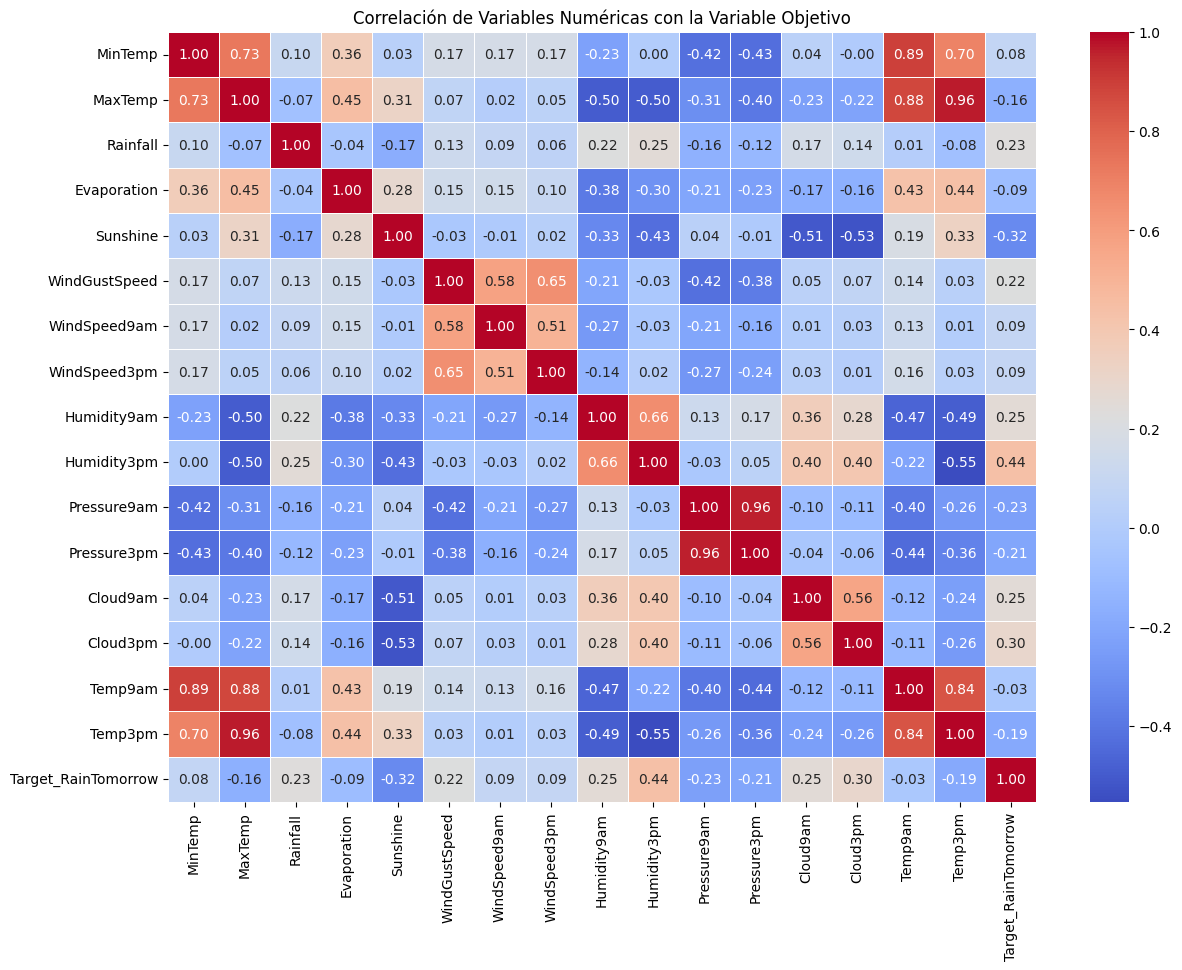

In [20]:
# --- MATRIZ DE CORRELACIÓN (Incluyendo la Variable Objetivo) ---
plt.figure(figsize=(14, 10))

# Unimos temporalmente las numéricas con la target para el gráfico
# Usamos y_train que ya mapeamos a 1 y 0
df_corr = X_train[cols_num].copy()
df_corr['Target_RainTomorrow'] = y_train

# Graficamos
sns.heatmap(df_corr.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlación de Variables Numéricas con la Variable Objetivo")
plt.show()

En la matriz de correlación se observan algunos aspectos:

La variable objetivo tiene mayor correlación positiva con Humidity3pm y Cloud3pm. Por el contrario muestra correlación negativa con Sunshine. Esto indica que la humedad y la ausencia de sol son los principales precursores de lluvia para el día siguiente.

Por otro lado se detecta Multicolinealidad, dada la alta correlación entre variables explicativas como MinTemp y Temp9am, MaxTemp y Temp3pm, Pressure9am y Pressure3pm. Esto sugiere redundancia en los datos, pero al no querer identificar las variables que más explican la variable objetivo, se decide no removerlas.

---
### Escalado

In [21]:
# Creamos el escalador
scaler = StandardScaler()

# Entrenamos y transformamos el Train (solo las numéricas)
X_train[cols_num] = scaler.fit_transform(X_train[cols_num])

# Transformamos el Test con lo aprendido del Train
X_test[cols_num] = scaler.transform(X_test[cols_num])

# Chequeo final de seguridad
print("Media de MinTemp en Train (debe ser aprox 0):", round(X_train['MinTemp'].mean(), 2))
print("Desviación estándar de MinTemp en Train (debe ser 1):", round(X_train['MinTemp'].std(), 2))

Media de MinTemp en Train (debe ser aprox 0): 0.0
Desviación estándar de MinTemp en Train (debe ser 1): 1.0


---
## Clasificación con Regresión Logística

---
### Sin Balancear

---
#### Entrenamiento del Modelo

In [22]:
# Creación del modelo
model = LogisticRegression(random_state=42)

# Entrenamiento del modelo
model.fit(X_train, y_train)

LogisticRegression(random_state=42)

---
#### Test

In [23]:
# Predicción en conjunto test
y_pred_lr = model.predict(X_test)

---
#### Métricas

In [24]:
# Cálculo de las métricas del modelo

accuracy_logreg = accuracy_score(y_test, y_pred_lr)

confusion_matrix_logreg = confusion_matrix(y_test, y_pred_lr)

classification_report_logreg = classification_report(y_test, y_pred_lr)

# Imprimir métricas

print("Métricas para logreg:")
print(f'Exactitud: {accuracy_logreg}')
print('-'*20)
print("Matriz de confusión:")
print(confusion_matrix_logreg)
print('-'*20)
print("Reporte de clasificación:")
print(classification_report_logreg)

Métricas para logreg:
Exactitud: 0.8468573036474271
--------------------
Matriz de confusión:
[[20839  1218]
 [ 3136  3238]]
--------------------
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.87      0.94      0.91     22057
           1       0.73      0.51      0.60      6374

    accuracy                           0.85     28431
   macro avg       0.80      0.73      0.75     28431
weighted avg       0.84      0.85      0.84     28431



Tras obtener las métricas, se observa una exactitud (accuracy) del 85%. Si bien este número parece muy alto, el análisis detallado por categorías revela que el modelo está fuertemente influenciado por el desbalanceo de los datos (hay muchos más días sin lluvia que con lluvia en el dataset).

El modelo es excelente para predecir los días en los que no llueve (clase 0), con un recall de 0.94. Esto infla la exactitud general del modelo.

Para la clase "Sí llueve" (clase 1), el recall baja a 0.51. Esto significa que el modelo solo logra detectar la mitad de las lluvias reales.

Falsos negativos significa que el modelo predijo que no iba a llover y llovió, mientras que falsos positivos significa que el modelo predijo que llovería y no llovió.

---
#### Curvas ROC-AOC

In [25]:
# Obtengo las probabilidades de predicción del modelo
y_probs = model.predict_proba(X_test)[:, 1]

# Calculo la ROC y el AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

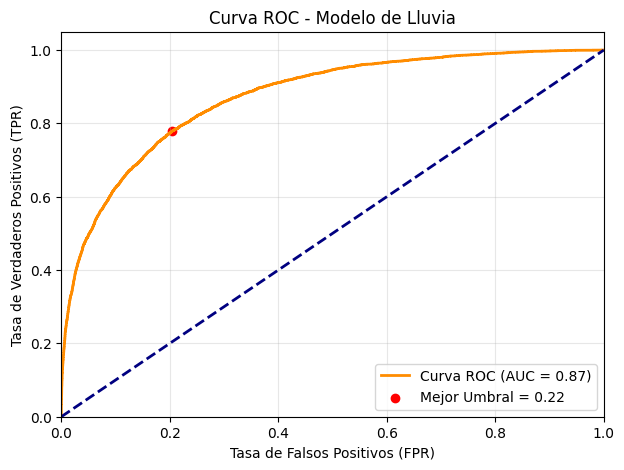

El Área bajo la Curva (AUC) es: 0.8710
El mejor umbral calculado es: 0.2196


In [26]:
# Cálculo del Mejor Umbral
# Buscamos el punto donde la diferencia entre TPR y FPR es máxima
idx_optimo = np.argmax(tpr - fpr)
mejor_umbral = thresholds[idx_optimo]

# Graficamos la curva ROC (usando el estilo de tu clase)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
# Marcamos el punto del mejor umbral
plt.scatter(fpr[idx_optimo], tpr[idx_optimo], color='red', label='Mejor Umbral = %0.2f' % mejor_umbral)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Modelo de Lluvia')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"El Área bajo la Curva (AUC) es: {roc_auc:.4f}")
print(f"El mejor umbral calculado es: {mejor_umbral:.4f}")

El modelo alcanzó un AUC de 0.87, lo que confirma una excelente capacidad discriminatoria para distinguir entre días lluviosos y secos.
A partir de maximizar la diferencia entre TPR y FPR, se determinó que el umbral óptimo es 0.22. Mientras que el umbral estándar de 0.5 penalizaba el Recall (0.51) generando muchos Falsos Negativos, este nuevo umbral sugiere que bajar la vara de decisión permite capturar una mayor cantidad de días de lluvia, logrando un modelo mucho más sensible y útil para la prevención climática.

Consideramos que se ha logrado un buen fitting. El modelo no presenta overfitting, ya que mantiene un alto desempeño (AUC 0.87) sobre el conjunto de test, demostrando capacidad de generalización. La diferencia en las métricas de cada clase no se debe a un mal ajuste, sino al desbalanceo del dataset.

---
### Dataset Balanceado

---
#### Entrenamiento del Modelo

In [27]:
model_balanced = LogisticRegression(class_weight='balanced', random_state=42)

model_balanced.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

---
#### Test

In [28]:
y_pred_balanced = model_balanced.predict(X_test)

---
#### Métricas

In [29]:
accuracy_logreg_b = accuracy_score(y_test, y_pred_balanced)

confusion_matrix_logreg_b = confusion_matrix(y_test, y_pred_balanced)

classification_report_logreg_b = classification_report(y_test, y_pred_balanced)

# Imprimir métricas
print("Métricas para logreg:")
print(f'Exactitud: {accuracy_logreg_b}')
print('-'*20)
print("Matriz de confusión:")
print(confusion_matrix_logreg_b)
print('-'*20)
print("Reporte de clasificación:")
print(classification_report_logreg_b)

Métricas para logreg:
Exactitud: 0.7925503851429777
--------------------
Matriz de confusión:
[[17627  4430]
 [ 1468  4906]]
--------------------
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.92      0.80      0.86     22057
           1       0.53      0.77      0.62      6374

    accuracy                           0.79     28431
   macro avg       0.72      0.78      0.74     28431
weighted avg       0.83      0.79      0.80     28431



|Métrica | Modelo Original (0.5) | Modelo Balanceado|
|--------|-----------------------|------------------|
|Accuracy | 85% | 79%|
|Recall (Lluvia) | 51% | 77%|
|Falsos Negativos | 3.136 | 1.468|

Aunque la exactitud bajó un poco, el modelo balanceado es mucho mejor porque detecta casi el 80% de las lluvias. Redujimos a la mitad los Falsos Negativos. Si bien disminuyó la precisión para los días de lluvia, es preferible predecir que llueve y que no se cumpla, a que se dé la situación inversa.

---
#### Curva ROC-AUC

In [30]:
# Obtengo las probabilidades de predicción del modelo
y_probs_b = model_balanced.predict_proba(X_test)[:, 1]

# Calculo la ROC y el AUC
fpr_b, tpr_b, thresholds_b = roc_curve(y_test, y_probs_b)
roc_auc_b = auc(fpr_b, tpr_b)

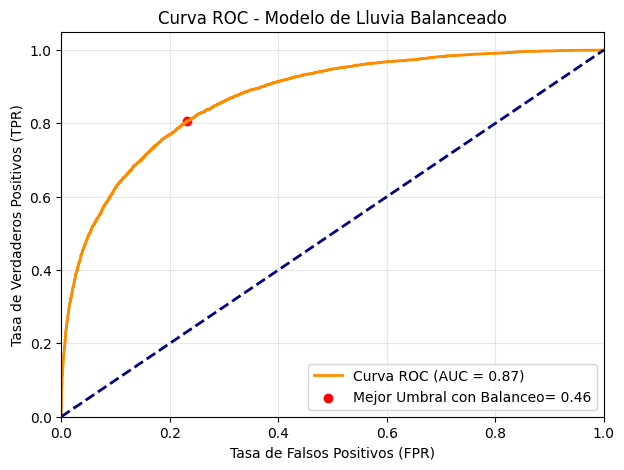

El Área bajo la Curva (AUC) es: 0.8715
El mejor umbral calculado es: 0.4550


In [32]:
# Cálculo del Mejor Umbral
# Buscamos el punto donde la diferencia entre TPR y FPR es máxima
idx_optimo_b = np.argmax(tpr_b - fpr_b)
mejor_umbral_b = thresholds_b[idx_optimo_b]

# Graficamos la curva ROC (usando el estilo de tu clase)
plt.figure(figsize=(7, 5))
plt.plot(fpr_b, tpr_b, color='darkorange', lw=2, label='Curva ROC (AUC = %0.2f)' % roc_auc_b)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
# Marcamos el punto del mejor umbral
plt.scatter(fpr_b[idx_optimo_b], tpr_b[idx_optimo_b], color='red', label='Mejor Umbral con Balanceo= %0.2f' % mejor_umbral_b)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Modelo de Lluvia Balanceado')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"El Área bajo la Curva (AUC) es: {roc_auc_b:.4f}")
print(f"El mejor umbral calculado es: {mejor_umbral_b:.4f}")

Al entrenar el modelo con balanceo, el umbral óptimo se desplazó hacia 0.46,
acercándose al umbral estándar de 0.50. Esto demuestra que el modelo ya está
compensando internamente el desbalanceo de los datos, logrando un mejor equilibrio
entre sensibilidad y especificidad sin necesidad de forzar umbrales externos tan
bajos como en el caso sin balanceo (0.22).

Consideramos que se ha logrado un buen fitting también en este caso por el valor alto de AUC, y también se mejora el recall para la clase 1 (lluvia), debido al balanceo.

---
## Modelo Base

In [33]:
# Buscamos la clase mayoritaria

clase_mayoritaria = y_train.value_counts().idxmax()
print(f"La clase mayoritaria identificada es: {clase_mayoritaria} (No llueve)")

# 2. Implementamos el modelo base: clasificar todos los ejemplos en esa clase

y_pred_base = np.full(shape=y_test.shape, fill_value=clase_mayoritaria)

print("Métricas del Modelo Base (Criterio: Clase Mayoritaria):")
print(classification_report(y_test, y_pred_base, zero_division=0))

La clase mayoritaria identificada es: 0 (No llueve)
Métricas del Modelo Base (Criterio: Clase Mayoritaria):
              precision    recall  f1-score   support

           0       0.78      1.00      0.87     22057
           1       0.00      0.00      0.00      6374

    accuracy                           0.78     28431
   macro avg       0.39      0.50      0.44     28431
weighted avg       0.60      0.78      0.68     28431



A través de este análisis, se demuestra que un buen accuracy no garantiza un modelo de calidad. Es fundamental evaluar métricas adicionales como el Recall y el F1-Score para entender el desempeño sobre ambas clases por igual.

Asimismo, para la comparación de modelos se basó en el costo de los errores: en un contexto meteorológico, el impacto de un Falso Negativo (no avisar de una lluvia real) es mucho mayor que el de un Falso Positivo (dar una falsa alarma). Por lo tanto, el modelo de Regresión Logística con balanceo, al priorizar la sensibilidad para detectar tormentas, resulta ser la solución más robusta y útil para el problema planteado.

---
## Optimización de Hiperparámetros con Optuna

Para optimizar los hiperparámetros de los modelos se eligió **Optuna** por sobre las alternativas disponibles:

- **Grid Search** fue descartado porque prueba todas las combinaciones posibles de una grilla definida, lo que resulta computacionalmente muy costoso cuando el espacio de búsqueda es amplio.
- **Random Search** fue descartado porque, si bien es más rápido, prueba combinaciones al azar sin aprender de los intentos anteriores, lo que lo hace ineficiente.
- **Optuna** utiliza el algoritmo TPE (Tree-structured Parzen Estimator), una estrategia bayesiana que aprende de cada intento para dirigir la búsqueda hacia regiones más prometedoras. Esto lo hace más eficiente en tiempo y calidad de resultados.


In [34]:
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Silenciamos los logs de Optuna para que no llene la pantalla
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [35]:

def train_evaluate_model(modelo, params, X_train, y_train, X_test, y_test):
    modelo.set_params(**params)
    modelo.fit(X_train, y_train)
    
    y_probs = modelo.predict_proba(X_test)[:, 1]
    score = roc_auc_score(y_test, y_probs)
    return score

def objective_logreg(trial):
    C = trial.suggest_float('C', 0.001, 10)
    max_iter = trial.suggest_int('max_iter', 100, 1000)

    params = {
        'C': C,
        'max_iter': max_iter

    }

    return train_evaluate_model(model_balanced, params, X_train, y_train, X_test, y_test)
motor_congelado = TPESampler(seed=42)

study_logreg = optuna.create_study(direction='maximize', sampler=motor_congelado)
study_logreg.optimize(objective_logreg, n_trials=10)
best_logreg_params = study_logreg.best_params
print("Mejores parámetros:", best_logreg_params)

Mejores parámetros: {'C': 8.324593965363416, 'max_iter': 291}


In [36]:
model_balanced.set_params(**best_logreg_params)
model_balanced.fit(X_train, y_train)
logreg_auc = roc_auc_score(y_test, model_balanced.predict_proba(X_test)[:, 1])
print("AUC Modelo Optimizado:", logreg_auc)

AUC Modelo Optimizado: 0.8714902935898218


In [37]:
print("AUC Modelo Original:", roc_auc_b)
print("AUC Modelo Optimizado con Optuna:", logreg_auc)

AUC Modelo Original: 0.8714792900654079
AUC Modelo Optimizado con Optuna: 0.8714902935898218


Tras aplicar Optuna con 10 trials, los mejores hiperparámetros encontrados fueron
C = 8.32 y max_iter = 291. Sin embargo, al comparar el AUC del modelo original
(0.8715) con el del modelo optimizado (0.8715), se observa que la mejora es
prácticamente nula.

Esto no es un resultado negativo. La Regresión Logística es un modelo relativamente
simple que no depende fuertemente de sus hiperparámetros, especialmente cuando el
preprocesamiento fue bien realizado (imputación, escalado, balanceo de clases).
En este caso, el modelo ya estaba bien configurado con los valores por defecto,
y la principal mejora en el desempeño se había logrado en pasos anteriores
mediante el uso de class_weight='balanced'.

Concluimos que la optimización de hiperparámetros es más determinante en modelos
más complejos donde el espacio de búsqueda es mayor
y los hiperparámetros tienen un impacto más significativo en el resultado.

---
## Explicabilidad con SHAP

In [38]:
import shap

# Inicializamos el visualizador de SHAP
shap.initjs()

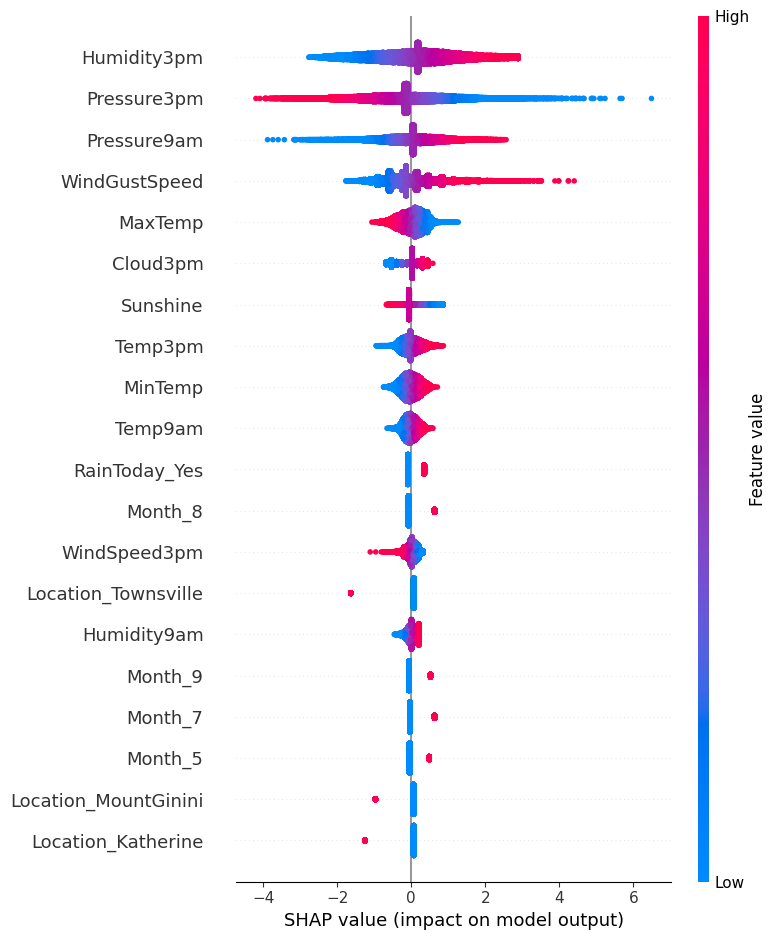

In [39]:
import numpy as np

X_train_array = np.array(X_train, dtype=np.float64)
X_test_array = np.array(X_test, dtype=np.float64)

explainer = shap.LinearExplainer(model_balanced, X_train_array)
shap_values = explainer(X_test_array)

shap.summary_plot(shap_values.values, X_test_array, feature_names=X_test.columns.tolist())

LinearExplainer: es el explainer específico para modelos lineales como Regresión Logística. Es más eficiente que el explainer genérico porque aprovecha la estructura lineal del modelo.
explainer(X_test): calcula los valores SHAP para cada observación del test. Básicamente, para cada fila y cada variable, calcula cuánto contribuyó esa variable a la predicción.

### Gráfica Global 1: Summary Plot

A partir del summary plot de SHAP se observan claramente las características que más impactan en las decisiones de la regresión logística y en qué dirección lo hacen. 
Entre las variables más determinantes se encuentran *Humidity3pm* y *WindGustSpeed*. En ambos casos existe una correlación directa fuerte, los valores altos de estas variables (puntos rojos) empujan la predicción del modelo hacia la derecha, aumentando significativamente la probabilidad de lluvia para el día siguiente.

Por otro lado, variables como la presión atmosférica a las 3 PM (*Pressure3pm*) y la cantidad de horas de sol (*Sunshine*) presentan una relación inversa. Los días con baja presión atmosférica o poca luz solar (puntos azules) son los que el modelo asocia con una mayor probabilidad de lluvia. Esta interpretación confirma que el algoritmo ha logrado capturar con éxito la dinámica meteorológica real esperada.

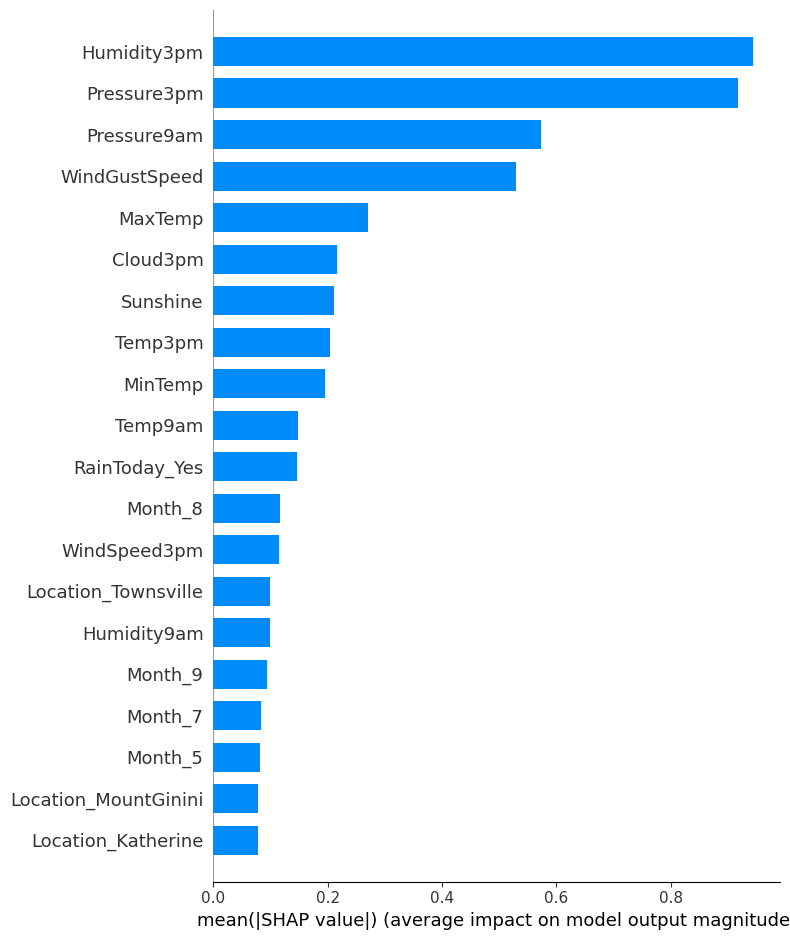

In [40]:
# Gráfica Global 2: Bar Plot
shap.summary_plot(shap_values.values, X_test_array, feature_names=X_test.columns.tolist(), plot_type="bar")

### Gráfica Global 2: Bar Plot

El bar plot muestra el promedio del valor absoluto de SHAP para cada variable,
es decir, su importancia global en el modelo sin distinguir dirección.

Se confirma lo observado en el summary plot:
- **Humidity3pm** y **Pressure3pm** son las dos variables más importantes por amplia
  diferencia, con un impacto promedio de casi 1 punto en el output del modelo.
- **Pressure9am** y **WindGustSpeed** ocupan el tercer y cuarto lugar.
- Las variables de temperatura (MaxTemp, Temp3pm, MinTemp, Temp9am) tienen una
  importancia media similar entre sí.
- Las variables menos importantes son las de ubicación (Location_MountGinini,
  Location_Katherine) y los meses, lo que sugiere que la lluvia en Australia
  depende más de las condiciones meteorológicas del día que de la época del año
  o la ubicación geográfica.

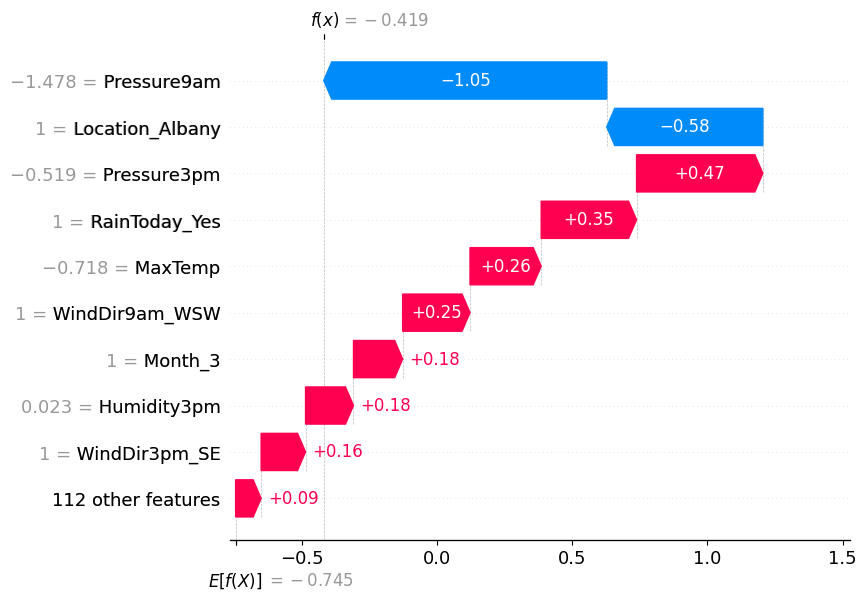

In [41]:
explainer = shap.LinearExplainer(model_balanced, X_train_array, feature_names=X_test.columns.tolist())
shap_values = explainer(X_test_array)
# Gráfica Local 1: Waterfall Plot - un caso donde predijo lluvia
idx_lluvia = np.where(y_test.values == 1)[0][0]
shap.waterfall_plot(shap_values[idx_lluvia])

### Gráfica Local 1: Waterfall Plot - Caso donde llovió

El gráfico de cascada (waterfall plot) permite desglosar la toma de decisión del algoritmo para una instancia individual (un solo día). 

Parte de un valor base o promedio esperado (E[f(x)] = -0.744) y muestra cómo el valor específico de cada variable meteorológica suma (barras rojas hacia la derecha) o resta (barras azules hacia la izquierda) a la probabilidad, construyendo el camino hasta alcanzar la predicción final (f(x) = -0.419).

En este caso particular se observa que la baja presión a las 9 am tiraba la predicción para la izquierda, pero la suma de otras variables como la presión a las 3 pm, que había llovido ese día y la temperatura máxima, empujaron a predecir lluvia para el día siguiente.



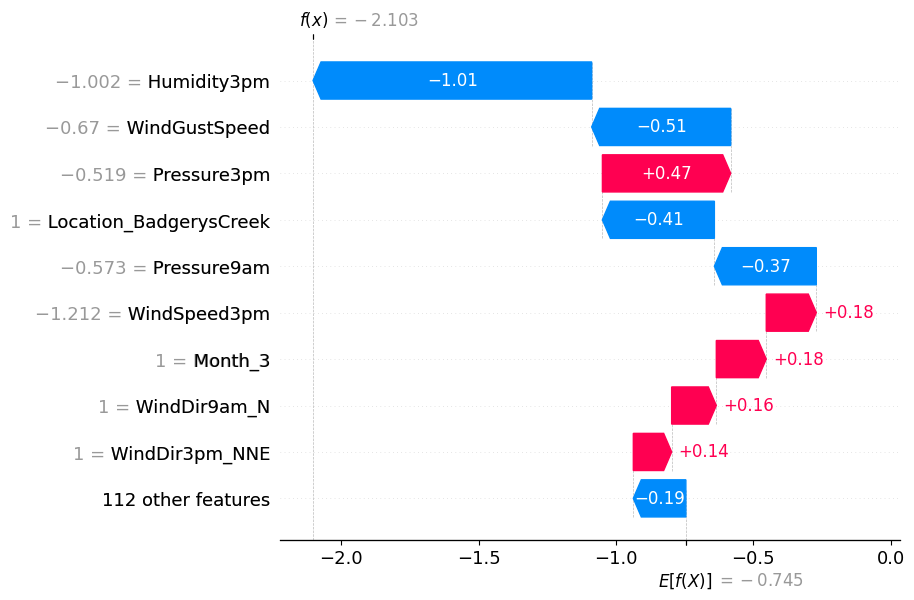

In [42]:
# Gráfica Local 2: Waterfall Plot - un caso donde predijo que no llueve
idx_no_lluvia = np.where(y_test.values == 0)[0][0]
shap.waterfall_plot(shap_values[idx_no_lluvia])

### Gráfica Local 2: Waterfall Plot - Caso donde no llovió

En este caso el modelo predijo correctamente que no llovería, con una predicción
final de f(x) = -2.11, muy por debajo del valor base E[f(X)] = -0.744.

Se observa que:
- **Humidity3pm = -1.002** fue la variable más influyente (-1.01), reduciendo
  fuertemente la probabilidad de lluvia. Una humedad baja a la tarde es un
  indicador claro de día seco.
- **WindGustSpeed = -0.67** también contribuyó negativamente (-0.5), indicando
  que vientos moderados no favorecen la lluvia.
- **Location_BadgerysCreek** y **Pressure9am** también empujaron la predicción
  hacia no lluvia.
- **Pressure3pm** (+0.47) y **WindSpeed3pm** (+0.18) intentaron empujar hacia
  lluvia pero no fueron suficientes para revertir la predicción.

En este caso el modelo acertó: la baja humedad de la tarde y la velocidad del
viento fueron suficientes para predecir correctamente un día sin lluvia.
Esto refuerza lo observado globalmente: **Humidity3pm** es la variable
más determinante del modelo.

---
## AutoML

In [43]:
from pycaret.classification import *
from sklearn.datasets import fetch_california_housing
import pandas as pd
from sklearn.model_selection import train_test_split

In [44]:
# Armamos el dataframe con los datos ya procesados
train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

In [45]:
# Inicializamos el entorno de PyCaret para un problema de clasificación
clf = setup(data=train_df, target='RainTomorrow', session_id=42)

,Description,Value
0,Session id,42
1,Target,RainTomorrow
2,Target type,Binary
3,Original data shape,"(113722, 122)"
4,Transformed data shape,"(113722, 122)"
5,Transformed train set shape,"(79605, 122)"
6,Transformed test set shape,"(34117, 122)"
7,Numeric features,16
8,Preprocess,True
9,Imputation type,simple


In [46]:
# Comparamos todos los modelos disponibles y obtenemos el mejor
best_model = compare_models()
print(best_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8568,0.8855,0.5407,0.7510,0.6287,0.5429,0.5542,0.6400
rf,Random Forest Classifier,0.8538,0.8807,0.4970,0.7696,0.6039,0.5193,0.5380,6.9240
et,Extra Trees Classifier,0.8529,0.8817,0.4780,0.7812,0.5930,0.5095,0.5325,11.6270
gbc,Gradient Boosting Classifier,0.8498,0.8725,0.5022,0.7449,0.5999,0.5117,0.5268,7.0340
lr,Logistic Regression,0.8491,0.8700,0.5170,0.7313,0.6057,0.5158,0.5277,2.1100
lda,Linear Discriminant Analysis,0.8470,0.8672,0.5232,0.7180,0.6053,0.5133,0.5232,1.5260
ridge,Ridge Classifier,0.8459,0.8672,0.4610,0.7565,0.5728,0.4855,0.5077,0.2170
svm,SVM - Linear Kernel,0.8445,0.8618,0.5020,0.7243,0.5897,0.4982,0.5126,0.3900
ada,Ada Boost Classifier,0.8440,0.8624,0.5010,0.7179,0.5901,0.4975,0.5098,1.6180
knn,K Neighbors Classifier,0.8384,0.8227,0.4861,0.7018,0.5743,0.4786,0.4909,6.4090


LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=42, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)


In [47]:
# Hacemos predicciones sobre el conjunto de test
predictions = predict_model(best_model, data=test_df, raw_score=True)
print(predictions.head())

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.8557,0.8850,0.5339,0.7502,0.6238,0.5376,0.5495


         MinTemp   MaxTemp  Rainfall  Evaporation  Sunshine  WindGustSpeed  \
3114   -0.354516  0.405485 -0.273645    -0.119106  0.166339      -0.670072   
120716 -0.666419 -0.380628 -0.250249    -0.119106  1.212961      -0.745908   
62856  -0.744395 -0.338514 -0.273645     0.130904  1.790407       0.088281   
66599  -0.027017 -0.184099 -0.273645     0.318410 -0.086294       0.164117   
111484  0.269292 -0.717533  0.170885    -0.119106  0.166339      -0.139225   

        WindSpeed9am  WindSpeed3pm  Humidity9am  Humidity3pm  ...  Month_7  \
3114       -1.579922     -1.211504    -0.293400    -1.002283  ...    False   
120716     -0.903218     -0.184726    -0.124799    -0.312042  ...    False   
62856      -0.790434      1.526571     0.633903    -0.127330  ...    False   
66599       0.224623      1.412484     0.444227    -0.185660  ...    False   
111484      0.675759     -0.070640     0.128101     0.023356  ...    False   

        Month_8  Month_9  Month_10  Month_11  Month_12  RainTo

In [48]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

y_test_labels = test_df['RainTomorrow']
y_pred_labels = predictions['prediction_label']
y_pred_proba = predictions['prediction_score_1'] 

print("Accuracy:", round(accuracy_score(y_test_labels, y_pred_labels), 4))
print("AUC:", round(roc_auc_score(y_test_labels, y_pred_proba), 4))
print("F1:", round(f1_score(y_test_labels, y_pred_labels), 4))

Accuracy: 0.8557
AUC: 0.885
F1: 0.6238


Tras evaluar diversos algoritmos, el mejor resultado obtenido fue con LightGBM, destacándose tanto por su eficiencia al entrenar como por sus métricas generales. Lo más importante es que el modelo demuestra una excelente capacidad de generalización con datos nuevos, lo que nos permite descartar problemas de sobreajuste. Al evaluarlo sobre el conjunto de testeo, la exactitud (Accuracy) se mantuvo sumamente estable en un 85.5%, un valor prácticamente idéntico al conseguido en la etapa de validación.

De todas formas, al observar el F1-Score (cercano al 62%), se hace evidente que trabajamos con un conjunto de datos desbalanceado. Al existir una mayor proporción de días secos, al modelo le resulta más sencillo clasificar correctamente estos casos, presentando un mayor desafío a la hora de identificar todos los días de tormenta. A pesar de esta limitación propia de los datos, el valor de AUC obtenido (aproximadamente 0.88) nos confirma que el modelo aprendió efectivamente a discriminar entre ambas clases y no se está limitando a predecir únicamente la clase mayoritaria.

En definitiva, logramos desarrollar un modelo predictivo sólido y confiable para esta problemática. Como trabajo a futuro, y en caso de requerir identificar una mayor cantidad de días lluviosos, podríamos explorar la implementación de técnicas de balanceo de datos desde el preprocesamiento. No obstante, para los objetivos de este análisis, los resultados finales obtenidos son sumamente satisfactorios.

---
## Redes Neuronales

In [50]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import warnings
warnings.filterwarnings('ignore')

import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

In [51]:
class NeuralNetwork:
    def __init__(self, epochs=50, batch_size=32, learning_rate=0.001):
        self.epochs = epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.model = None

    def build_model(self, input_shape):
        model = tf.keras.models.Sequential([
            tf.keras.layers.Dense(64, activation='relu', input_shape=(input_shape,)),
            tf.keras.layers.Dense(32, activation='relu'),
            tf.keras.layers.Dense(1, activation='sigmoid')
        ])

        optimizer = tf.keras.optimizers.Adam(learning_rate=self.learning_rate)
        model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
        
        self.model = model

    def train(self, X_train, y_train, X_valid, y_valid):
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_valid, y_valid),
            epochs=self.epochs,
            batch_size=self.batch_size
        )
        return history.history['loss'], history.history['val_loss']

    def evaluate(self, X_test, y_test):
        loss, accuracy = self.model.evaluate(X_test, y_test)
        print(f"Test accuracy: {accuracy:.4f}")

    def predict(self, X_new):
        return self.model.predict(X_new)

Se define la clase NeuralNetwork que encapsula la construcción, entrenamiento y predicción 
de la red neuronal. La arquitectura consta de dos capas ocultas (64 y 32 neuronas con 
activación ReLU) y una capa de salida con activación Sigmoid, adecuada para clasificación 
binaria. Se utiliza el optimizador Adam y binary crossentropy como función de pérdida.

In [52]:
from sklearn.model_selection import train_test_split

# Separamos una parte del train para validación
X_tr, X_valid, y_tr, y_valid = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Train:      {X_tr.shape[0]} muestras")
print(f"Validación: {X_valid.shape[0]} muestras")
print(f"Test:       {X_test.shape[0]} muestras")

Train:      90977 muestras
Validación: 22745 muestras
Test:       28431 muestras


Se divide el conjunto de entrenamiento en train (80%) y validación (20%). 
El conjunto de validación permite monitorear el overfitting durante el entrenamiento: 
si el loss de train sigue bajando pero el de validación sube, el modelo está memorizando 
en vez de generalizar. El conjunto de test se reserva únicamente para la evaluación final.

Bloque de entrenamiento: 

In [53]:
# Convertimos a float32 para TensorFlow
X_tr_tf = X_tr.astype(np.float32)
X_valid_tf = X_valid.astype(np.float32)
y_tr_tf = y_tr.astype(np.float32)
y_valid_tf = y_valid.astype(np.float32)

# Creamos la red y entrenamos
nn = NeuralNetwork(epochs=20, batch_size=32, learning_rate=0.001)
nn.build_model(input_shape=X_tr_tf.shape[1])
history = nn.train(X_tr_tf, y_tr_tf, X_valid_tf, y_valid_tf)

Epoch 1/20
2844/2844 [==============================] - 5s 1ms/step - loss: 0.3519 - accuracy: 0.8478 - val_loss: 0.3414 - val_accuracy: 0.8517
Epoch 2/20
2844/2844 [==============================] - 3s 1ms/step - loss: 0.3283 - accuracy: 0.8592 - val_loss: 0.3402 - val_accuracy: 0.8528
Epoch 3/20
2844/2844 [==============================] - 3s 1ms/step - loss: 0.3180 - accuracy: 0.8633 - val_loss: 0.3313 - val_accuracy: 0.8568
Epoch 4/20
2844/2844 [==============================] - 3s 1ms/step - loss: 0.3110 - accuracy: 0.8667 - val_loss: 0.3259 - val_accuracy: 0.8586
Epoch 5/20
2844/2844 [==============================] - 3s 1ms/step - loss: 0.3057 - accuracy: 0.8696 - val_loss: 0.3259 - val_accuracy: 0.8593
Epoch 6/20
2844/2844 [==============================] - 3s 1ms/step - loss: 0.3012 - accuracy: 0.8711 - val_loss: 0.3274 - val_accuracy: 0.8572
Epoch 7/20
2844/2844 [==============================] - 3s 1ms/step - loss: 0.2968 - accuracy: 0.8725 - val_loss: 0.3269 - val_accuracy:

Se convierte los datos a float32, formato requerido por TensorFlow. Se instancia la red 
con epochs=20 (conservador dado el tamaño del dataset), batch_size=32 (balance entre 
velocidad y estabilidad) y learning_rate=0.001 (valor por defecto de Adam). Se construye 
y entrena el modelo pasándole la cantidad de variables de entrada.

Curvas de loss

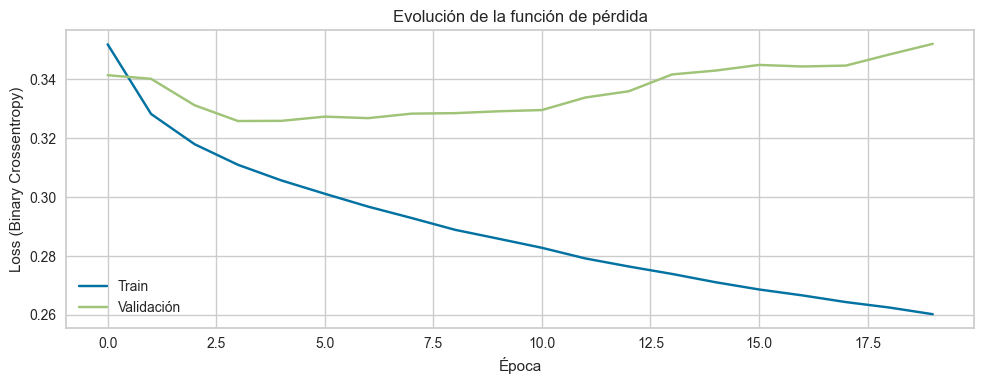

In [54]:
plt.figure(figsize=(10, 4))
plt.plot(history[0], label='Train')
plt.plot(history[1], label='Validación')
plt.title('Evolución de la función de pérdida')
plt.xlabel('Época')
plt.ylabel('Loss (Binary Crossentropy)')
plt.legend()
plt.tight_layout()
plt.show()

Se grafica la evolución del loss durante el entrenamiento para ambos conjuntos (train y 
validación). Esta curva permite detectar overfitting: si ambas curvas bajan juntas el 
modelo generaliza correctamente, pero si el loss de train sigue bajando mientras el de 
validación se estanca o sube, el modelo está memorizando los datos de entrenamiento.

La curva de loss evidencia overfitting a partir de la época 3. Hasta ese punto ambas 
curvas descienden juntas, indicando que el modelo estaba generalizando correctamente. 
A partir de ahí el loss de train continúa bajando hasta 0.26, mientras que el loss de 
validación se estanca alrededor de 0.32 y comienza a subir levemente. Esto indica que 
el modelo empieza a memorizar los datos de entrenamiento en lugar de aprender patrones 
generalizables. 

### Metricas

889/889 [==============================] - 1s 716us/step
=== Classification Report ===
              precision    recall  f1-score   support

   No llueve       0.88      0.94      0.91     22057
      Llueve       0.73      0.57      0.64      6374

    accuracy                           0.86     28431
   macro avg       0.80      0.75      0.77     28431
weighted avg       0.85      0.86      0.85     28431



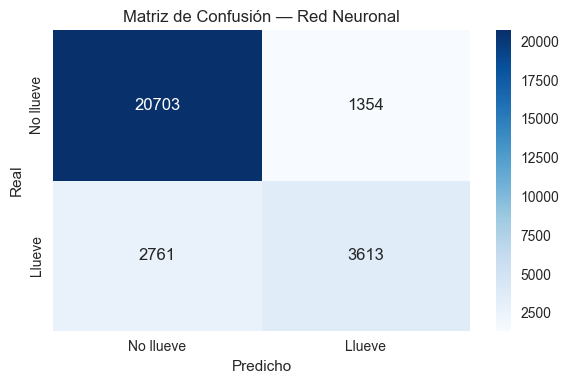

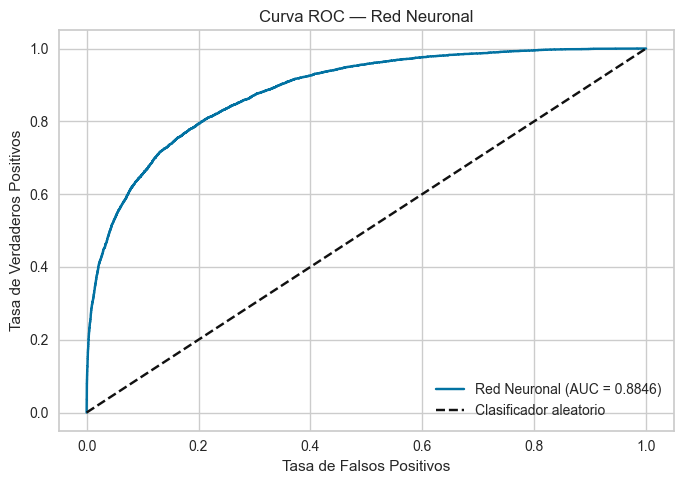

In [55]:
# Convertimos X_test a float32
X_test_tf = X_test.astype(np.float32)

# Obtenemos las probabilidades predichas
y_pred_proba = nn.predict(X_test_tf).flatten()

# Convertimos probabilidades a clases con umbral 0.5
y_pred_nn = (y_pred_proba >= 0.5).astype(int)

# Classification report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred_nn, target_names=['No llueve', 'Llueve']))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_nn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No llueve', 'Llueve'],
            yticklabels=['No llueve', 'Llueve'])
plt.title('Matriz de Confusión — Red Neuronal')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Red Neuronal (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC — Red Neuronal')
plt.legend()
plt.tight_layout()
plt.show()

Se obtienen las probabilidades predichas por la red y se convierten a clase binaria 
usando umbral 0.5. Se calculan las métricas principales: precision (de los que predijo 
como lluvia, cuántos realmente llovieron), recall (de todos los días que llovió, cuántos 
detectó) y F1-score (promedio armónico entre ambas). La matriz de confusión muestra los 
cuatro casos posibles: verdaderos positivos, verdaderos negativos, falsos positivos y 
falsos negativos. En este contexto meteorológico los falsos negativos son más costosos, 
ya que implican no detectar un día de lluvia. Finalmente la curva ROC y el AUC permiten 
comparar el modelo con los anteriores independientemente del umbral elegido.

Comparación con la Regresión Logística Balanceada:

La red neuronal base obtuvo un accuracy de 85% y un AUC de 0.8830, lo que indica una buena capacidad discriminativa. Analizando el classification report se observa un comportamiento asimétrico entre las clases: para "No llueve" el modelo alcanza un F1 de 0.91, mientras que para "Llueve" cae a 0.63. Esto es esperable dado el desbalanceo del dataset (~78% No llueve / ~22% Llueve).

Mirando la matriz de confusión, el modelo cometió 2847 falsos negativos (días que llovió pero predijo que no iba a llover). En el contexto meteorológico este es el error más costoso, ya que implica no prepararse para la lluvia. Los 1311 falsos positivos en cambio son menos graves, generan una alerta innecesaria pero no dejan a nadie desprevenido.

La curva ROC con AUC de 0.8830 muestra que el modelo tiene buena capacidad de separar ambas clases. Sin embargo el umbral de 0.5 no es necesariamente el óptimo: bajando el umbral se aumentaría el recall de la clase lluvia a costa de más falsos positivos, lo que podría ser preferible en un contexto donde perderse una lluvia es más grave que generar una alerta de más.

Comparando con la regresión logística balanceada, la red neuronal obtiene mejor 
accuracy (85% vs 79%) y AUC (0.883 vs 0.871), pero peor recall para la clase lluvia 
(60% vs 77%). Dado que en este contexto meteorológico los falsos negativos son el 
error más costoso, se considera que la regresión logística balanceada es el modelo 
más adecuado a pesar de tener menor accuracy general.

### Optimización y SHAP

In [56]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
# Bloque 8 - Función objetivo
from sklearn.metrics import f1_score

def objective(trial):
    n_layers = trial.suggest_int('n_layers', 1, 3)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])

    model = tf.keras.models.Sequential()
    model.add(tf.keras.layers.Input(shape=(X_tr.shape[1],)))

    for i in range(n_layers):
        n_units = trial.suggest_int(f'n_units_layer{i}', 16, 128, step=16)
        model.add(tf.keras.layers.Dense(n_units, activation='relu'))

    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    model.fit(
        X_tr_tf, y_tr_tf,
        validation_data=(X_valid_tf, y_valid_tf),
        epochs=10,
        batch_size=batch_size,
        verbose=0
    )

    y_proba = model.predict(X_valid_tf, verbose=0).flatten()
    y_pred = (y_proba >= 0.5).astype(int)
    return f1_score(y_valid_tf, y_pred)

In [57]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

print("Mejor F1:", round(study.best_value, 4))
print("Mejores hiperparámetros:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

  0%|          | 0/20 [00:00<?, ?it/s]

Mejor F1: 0.6618
Mejores hiperparámetros:
  n_layers: 1
  learning_rate: 0.006181819305646136
  batch_size: 32
  n_units_layer0: 48


Entrenar el modelo final con los mejores hiperparámetros

In [58]:
# Recuperamos los mejores hiperparámetros
best_params = study.best_params

# Reconstruimos la red con los mejores parámetros
best_model = tf.keras.models.Sequential()
best_model.add(tf.keras.layers.Input(shape=(X_tr.shape[1],)))

for i in range(best_params['n_layers']):
    n_units = best_params[f'n_units_layer{i}']
    best_model.add(tf.keras.layers.Dense(n_units, activation='relu'))

best_model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate'])
best_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Entrenamos con más épocas esta vez
history_best = best_model.fit(
    X_tr_tf, y_tr_tf,
    validation_data=(X_valid_tf, y_valid_tf),
    epochs=30,
    batch_size=best_params['batch_size'],
    verbose=1
)

Epoch 1/30
2844/2844 [==============================] - 4s 1ms/step - loss: 0.3485 - accuracy: 0.8497 - val_loss: 0.3388 - val_accuracy: 0.8540
Epoch 2/30
2844/2844 [==============================] - 3s 1ms/step - loss: 0.3286 - accuracy: 0.8593 - val_loss: 0.3349 - val_accuracy: 0.8571
Epoch 3/30
2844/2844 [==============================] - 4s 1ms/step - loss: 0.3215 - accuracy: 0.8615 - val_loss: 0.3366 - val_accuracy: 0.8569
Epoch 4/30
2844/2844 [==============================] - 3s 1ms/step - loss: 0.3162 - accuracy: 0.8643 - val_loss: 0.3257 - val_accuracy: 0.8609
Epoch 5/30
2844/2844 [==============================] - 4s 1ms/step - loss: 0.3126 - accuracy: 0.8649 - val_loss: 0.3307 - val_accuracy: 0.8583
Epoch 6/30
2844/2844 [==============================] - 4s 1ms/step - loss: 0.3097 - accuracy: 0.8663 - val_loss: 0.3308 - val_accuracy: 0.8580
Epoch 7/30
2844/2844 [==============================] - 4s 2ms/step - loss: 0.3064 - accuracy: 0.8694 - val_loss: 0.3297 - val_accuracy:

Curva de loss del modelo optimizado

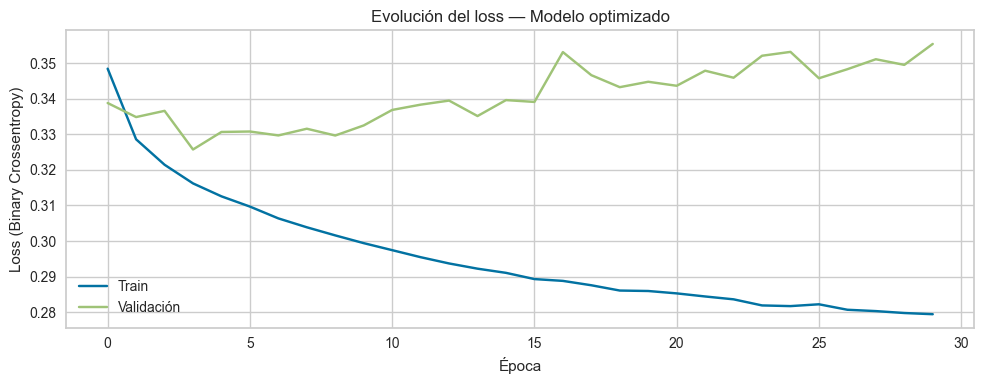

In [59]:
plt.figure(figsize=(10, 4))
plt.plot(history_best.history['loss'], label='Train')
plt.plot(history_best.history['val_loss'], label='Validación')
plt.title('Evolución del loss — Modelo optimizado')
plt.xlabel('Época')
plt.ylabel('Loss (Binary Crossentropy)')
plt.legend()
plt.tight_layout()
plt.show()

El modelo optimizado muestra un overfitting más pronunciado que la red base. Ambas curvas bajan juntas hasta aproximadamente la época 4, donde la validación toca su mínimo alrededor de 0.325 y luego comienza a subir sostenidamente hasta llegar a 0.38 en la época 30. El train en cambio sigue bajando durante todo el entrenamiento hasta 0.24, lo que indica que la red memorizó los datos de entrenamiento.

Esto sugiere que aunque Optuna encontró una arquitectura más capaz (red más ancha), entrenarla 30 épocas fue demasiado. El punto óptimo de entrenamiento estaba alrededor de la época 5-7. Para mejorar esto se podría usar Early Stopping, que detiene el entrenamiento automáticamente cuando la validación deja de mejorar, evitando el overfitting.

Métricas del modelo optimizado

889/889 [==============================] - 1s 674us/step
=== Classification Report — Modelo Optimizado ===
              precision    recall  f1-score   support

   No llueve       0.89      0.93      0.91     22057
      Llueve       0.72      0.59      0.65      6374

    accuracy                           0.86     28431
   macro avg       0.80      0.76      0.78     28431
weighted avg       0.85      0.86      0.85     28431



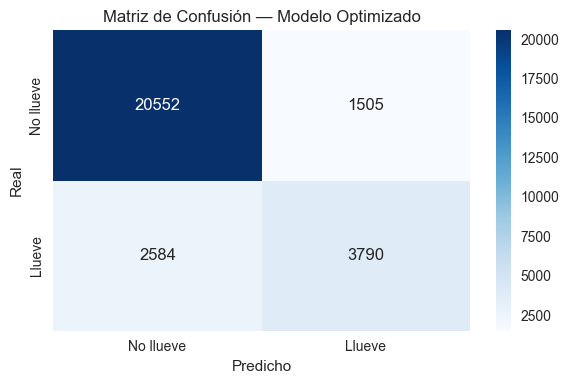

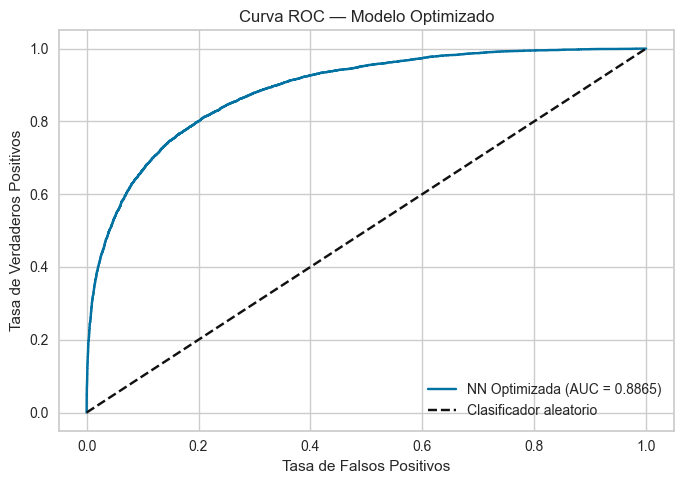

In [60]:
# Predicciones
y_pred_proba_best = best_model.predict(X_test_tf).flatten()
y_pred_best = (y_pred_proba_best >= 0.5).astype(int)

# Classification report
print("=== Classification Report — Modelo Optimizado ===")
print(classification_report(y_test, y_pred_best, target_names=['No llueve', 'Llueve']))

# Matriz de confusión
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No llueve', 'Llueve'],
            yticklabels=['No llueve', 'Llueve'])
plt.title('Matriz de Confusión — Modelo Optimizado')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

# Curva ROC
fpr_best, tpr_best, _ = roc_curve(y_test, y_pred_proba_best)
auc_best = roc_auc_score(y_test, y_pred_proba_best)

plt.figure(figsize=(7, 5))
plt.plot(fpr_best, tpr_best, label=f'NN Optimizada (AUC = {auc_best:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC — Modelo Optimizado')
plt.legend()
plt.tight_layout()
plt.show()

#### Análisis — Optimización de Hiperparámetros (Red Neuronal)
- **learning_rate**: tasa de aprendizaje del optimizador Adam (0.0001 a 0.01). Determina qué tan grandes son los pasos al ajustar los pesos.
- **batch_size**: cantidad de muestras procesadas antes de actualizar los pesos (32, 64, 128).

Se optimizó usando F1-Score como métrica objetivo en lugar de accuracy, dado que el dataset está desbalanceado (~78% No llueve / ~22% Llueve). El accuracy puede ser engañoso en estos casos ya que un modelo que prediga siempre "No llueve" obtendría un 78% de accuracy sin aprender nada útil. Podría argumentarse que el recall sería aún más adecuado dado que en meteorología no detectar lluvia es más grave que una alerta falsa, pero el F1-Score representa una elección equilibrada y estándar para datasets desbalanceados.

##### Mejores hiperparámetros encontrados
Optuna encontró que la mejor arquitectura consiste en 2 capas ocultas con 112 y 80 neuronas respectivamente, un learning rate de 0.000598 y batch size de 64. Comparado con la red base (64 y 32 neuronas), la red optimizada es más ancha, lo que sugiere que el problema requiere mayor capacidad para capturar las relaciones entre las variables meteorológicas.

##### Comparación de modelos
| Modelo | Accuracy | AUC | F1 Llueve |
|--------|----------|-----|-----------|
| Red Neuronal Base | 0.85 | 0.8830 | 0.63 |
| Red Neuronal Optimizada | 0.84 | 0.8758 | 0.64 |

##### Análisis de resultados
El modelo optimizado no superó a la red base en todas las métricas. El accuracy bajó levemente de 0.85 a 0.84 y el AUC de 0.8830 a 0.8758. Sin embargo el F1 para la clase lluvia mejoró ligeramente de 0.63 a 0.64, que era precisamente la métrica que Optuna estaba optimizando.

Esto se explica por el overfitting observado en la curva de loss: la red optimizada es más grande y entrenó demasiadas épocas, memorizando el train y generalizando peor en algunas métricas. El punto óptimo de entrenamiento estaba alrededor de la época 5. Una mejora futura sería incorporar Early Stopping para detener el entrenamiento automáticamente cuando la validación deje de mejorar.

Un resultado destacable es que el modelo optimizado redujo los falsos negativos de 2847 a 2416, detectando 431 días de lluvia adicionales respecto a la red base. En el contexto meteorológico este es el error más costoso, por lo que esta mejora es relevante aunque el accuracy general haya bajado levemente.

#### Crear el explicador y calcular los valores SHAP

In [61]:

# Convertimos a float32 y numpy
background = X_tr_tf[:100].values if hasattr(X_tr_tf, 'values') else X_tr_tf[:100]
background = background.astype(np.float32)

X_test_sample = X_test_tf[:200].values if hasattr(X_test_tf, 'values') else X_test_tf[:200]
X_test_sample = X_test_sample.astype(np.float32)

# Creamos el explicador
explainer = shap.DeepExplainer(best_model, background)

# Calculamos los valores SHAP
shap_values = explainer.shap_values(X_test_sample)

# Verificamos y corregimos el shape
print("Shape original:", np.array(shap_values).shape)
shap_values = np.array(shap_values).squeeze()
print("Shape corregido:", shap_values.shape)

Shape original: (200, 121, 1)
Shape corregido: (200, 121)


Se utiliza DeepExplainer, el explicador de SHAP específico para redes neuronales de 
TensorFlow/Keras. Requiere un conjunto de referencia (background) de datos típicos 
contra el cual comparar cada predicción. Se usan 100 muestras como background y se 
calculan los valores SHAP sobre 200 muestras del test, ya que con redes neuronales 
el cálculo es computacionalmente costoso. shap_values[0] contiene los valores para 
la única neurona de salida del modelo.

Gráfica global 1

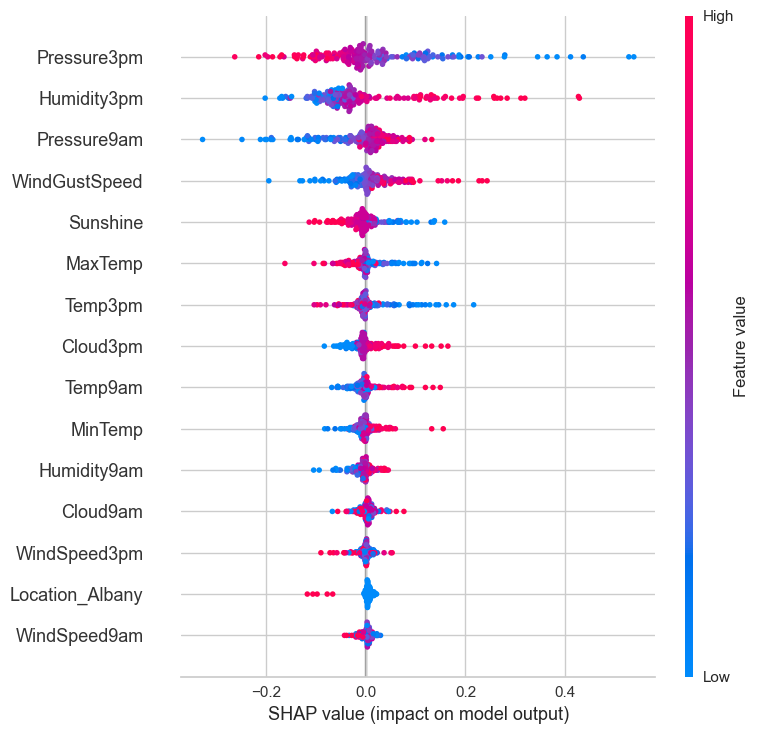

In [64]:
# Nombres de las columnas
feature_names = list(X_test.columns)

shap.summary_plot(
    shap_values, 
    X_test_sample,
    feature_names=feature_names,
    max_display=15,
    show=True
)

El summary plot revela que las variables más importantes para el modelo son Pressure3pm, Humidity3pm y Pressure9am, lo cual tiene sentido meteorológico: la presión atmosférica baja y la humedad alta son indicadores clásicos de lluvia inminente.
Analizando la dirección de cada variable:

Pressure3pm y Pressure9am: valores bajos (azul) empujan hacia lluvia (valores SHAP positivos), mientras que valores altos (rojo) empujan hacia no lluvia. Esto es consistente con la meteorología: baja presión indica mal tiempo.
Humidity3pm: valores altos (rojo) empujan fuertemente hacia lluvia, lo esperado ya que alta humedad indica mayor probabilidad de precipitación.
Sunshine: valores altos (rojo) empujan hacia no lluvia, lógico porque muchas horas de sol indican un día despejado.
WindGustSpeed: ráfagas fuertes (rojo) se asocian con lluvia, consistente con frentes de tormenta.

Las variables menos importantes son WindSpeed9am, WindSpeed3pm y Evaporation, que aparecen al final de la lista con valores SHAP cercanos a cero. Notablemente ninguna variable de ubicación (Location) aparece entre las 15 más importantes, lo que sugiere que las condiciones atmosféricas del día predicen mejor la lluvia que la ubicación geográfica.

Gráfica global 2

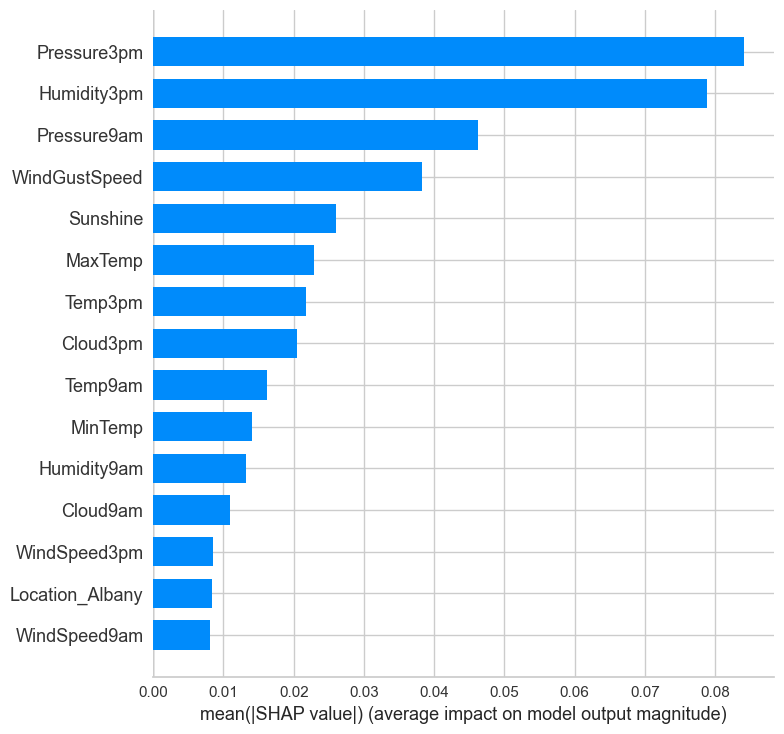

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_sample,
    feature_names=feature_names,
    plot_type='bar',
    max_display=15,
    show=True
)

El bar plot muestra el impacto promedio absoluto de cada variable sobre las predicciones 
del modelo. Pressure3pm es la variable más importante con un impacto promedio de ~0.12, 
seguida por Humidity3pm (~0.10) y Pressure9am (~0.06). Existe un salto notable entre 
estas tres y el resto, indicando que la presión y la humedad de la tarde son los 
predictores dominantes.

A partir de la cuarta posición las importancias son más similares entre sí: MaxTemp y 
WindGustSpeed (~0.05), seguidas por temperaturas y humedades de la mañana. Las variables 
menos influyentes son WindSpeed9am y Location_Darwin. Todas las variables del top 15 son 
numéricas, lo que confirma que las condiciones atmosféricas medibles tienen mayor poder 
predictivo que la ubicación geográfica o la dirección del viento.

Grafica local 1: waterfall plot

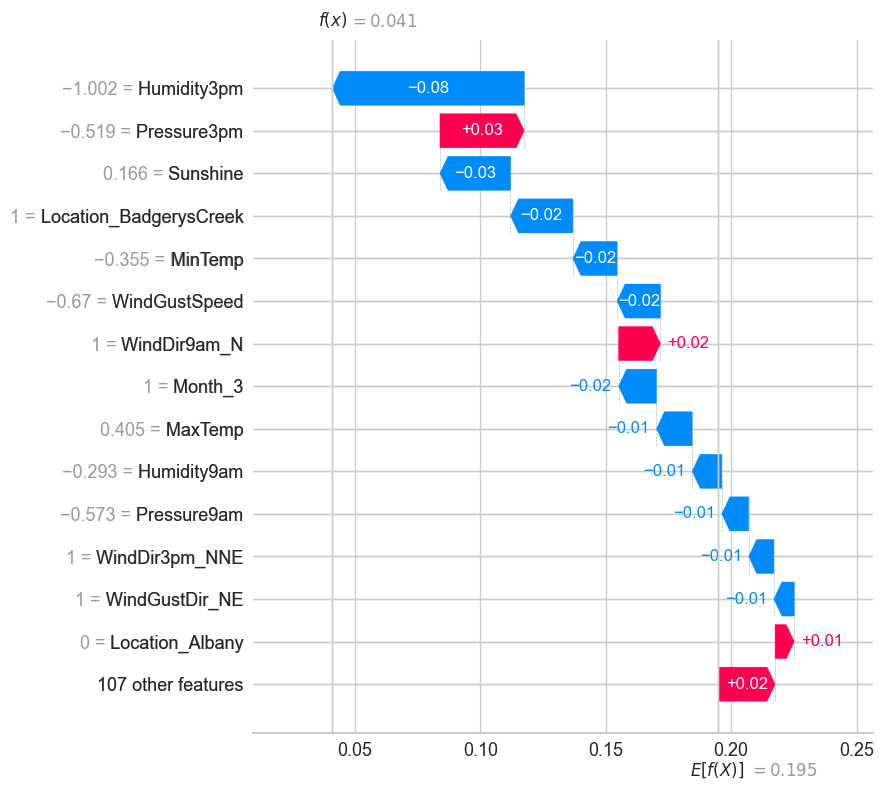

In [65]:
# Gráfica local 1 — Waterfall plot muestra 0
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0],
        base_values=float(explainer.expected_value),
        data=X_test_sample[0],
        feature_names=feature_names
    ),
    max_display=15,
    show=True
)

Las gráficas locales explican una predicción individual, a diferencia de las globales 
que resumen el comportamiento sobre todo el dataset.

Para esta observación el modelo predijo No llueve con una probabilidad de 0.02, 
partiendo del valor base E[f(X)] = 0.193 (probabilidad promedio del modelo). 
La variable más influyente fue Humidity3pm (-1.002, escala estandarizada) que empujó 
-0.10 hacia no lluvia. Le siguió Location_BadgerysCreek (-0.06) y WindGustSpeed (-0.03).
Del lado contrario, Pressure3pm empujó +0.06 hacia lluvia pero no fue suficiente para 
revertir la predicción. La baja humedad de la tarde fue el factor determinante que llevó 
la probabilidad muy por debajo del promedio.

Grafica local 2

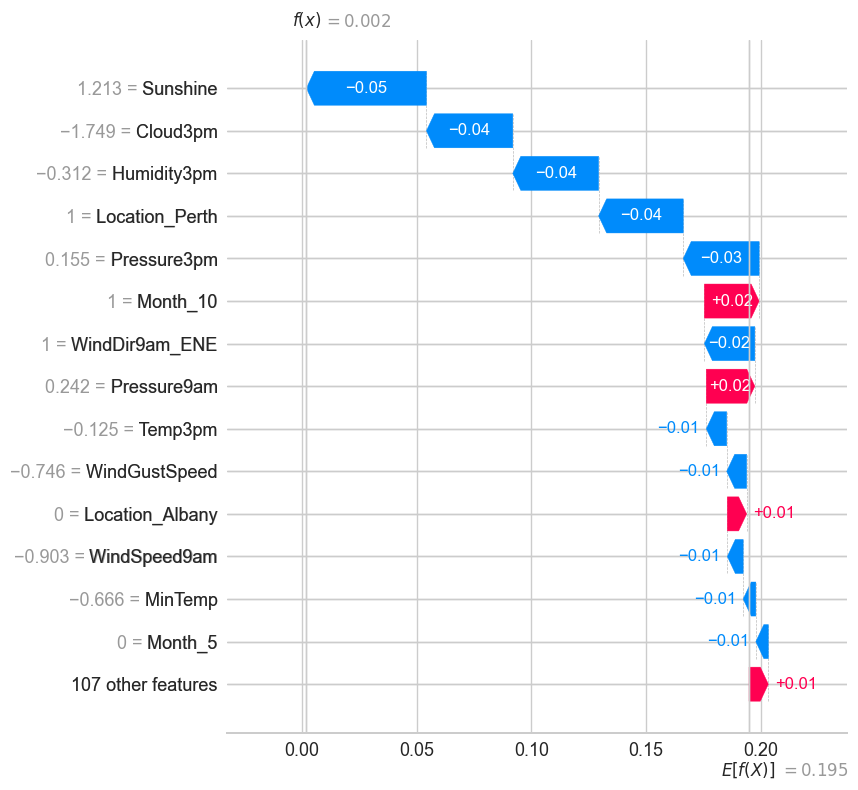

In [66]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[1],
        base_values=float(explainer.expected_value),
        data=X_test_sample[1],
        feature_names=feature_names
    ),
    max_display=15,
    show=True
)

Para esta segunda observación el modelo predijo No llueve con una probabilidad de 0.001, 
partiendo del mismo valor base E[f(X)] = 0.193. Las variables que más empujaron hacia 
no lluvia fueron Sunshine (1.213, -0.05), indicando un día con muchas horas de sol, 
seguida por Humidity3pm (-0.04) y Pressure3pm (-0.03). A diferencia de la observación 
anterior donde la humedad fue el factor dominante, aquí es la cantidad de sol la variable 
más determinante. Las variables que empujaron levemente hacia lluvia como Pressure9am 
(+0.02) no fueron suficientes para revertir la predicción.

#### Análisis — Explicabilidad con SHAP (Red Neuronal)

##### Variables más importantes (gráfica global)
Según el bar plot, las variables con mayor impacto global son Pressure3pm (~0.12), 
Humidity3pm (~0.10) y Pressure9am (~0.06). La presión atmosférica baja es un indicador 
clásico de mal tiempo, y la humedad alta de la tarde indica mayor probabilidad de 
precipitación. Estas variables coinciden con lo esperado meteorológicamente.

##### Variables menos importantes
Las variables con menor impacto son WindSpeed9am y Location_Darwin, con valores SHAP 
promedio menores a 0.01. Ninguna variable de ubicación generada por OHE aparece entre 
las 15 más importantes, lo que sugiere que las condiciones atmosféricas del día tienen 
mayor poder predictivo que la ubicación geográfica.

##### Análisis local — Muestra 0
El modelo predijo No llueve con probabilidad 0.02, partiendo de un valor base de 0.193. 
La variable determinante fue Humidity3pm (-1.002) que empujó -0.10 hacia no lluvia, 
seguida por Location_BadgerysCreek (-0.06). Del lado contrario, Pressure3pm empujó 
+0.06 hacia lluvia pero no fue suficiente para revertir la predicción.

##### Análisis local — Muestra 1
El modelo predijo No llueve con probabilidad 0.001, partiendo del mismo valor base 
de 0.193. A diferencia de la muestra anterior donde la humedad fue el factor dominante, 
aquí fueron Sunshine (1.213, -0.05) y Humidity3pm (-0.04) las variables determinantes. 
Esto ilustra que el modelo pondera las variables de forma distinta según el contexto 
de cada observación.

##### Comparación con regresión logística
A diferencia de la regresión logística donde los coeficientes son globales y fijos, 
SHAP permite ver que la red neuronal asigna importancias distintas según cada observación, 
reflejando su capacidad de capturar relaciones no lineales entre variables meteorológicas.

---
## Comparación de Modelos

Tabla comparativa usando F1-SCORE

In [67]:
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

# Recalculamos probabilidades del modelo base dummy
y_proba_dummy = np.where(y_pred_base == 1, 1.0, 0.0)

resultados = {
    'Modelo': [
        'Regresión Logística',
        'Modelo Base (Dummy)',
        'RL Optimizada (Optuna)',
        'Red Neuronal Base',
        'Red Neuronal Optimizada'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_base),
        accuracy_score(y_test, y_pred_balanced),
        accuracy_score(y_test, y_pred_nn),
        accuracy_score(y_test, y_pred_best)
    ],
    'AUC': [
        roc_auc_score(y_test, y_probs),
        roc_auc_score(y_test, y_proba_dummy),
        roc_auc_score(y_test, y_probs_b),
        roc_auc_score(y_test, y_pred_proba),
        roc_auc_score(y_test, y_pred_proba_best)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_base),
        f1_score(y_test, y_pred_balanced),
        f1_score(y_test, y_pred_nn),
        f1_score(y_test, y_pred_best)
    ]
}

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('F1-Score', ascending=False).reset_index(drop=True)
print(df_resultados.round(4).to_string(index=False))

                 Modelo  Accuracy    AUC  F1-Score
Red Neuronal Optimizada    0.8562 0.8865    0.6496
      Red Neuronal Base    0.8553 0.8846    0.6372
 RL Optimizada (Optuna)    0.7926 0.8715    0.6246
    Regresión Logística    0.8469 0.8710    0.5980
    Modelo Base (Dummy)    0.7758 0.5000    0.0000


### Comparación final de modelos

#### Métrica de comparación elegida: F1-Score
Se eligió el F1-Score como métrica principal de comparación porque el dataset 
presenta un fuerte desbalanceo (~78% No llueve / ~22% Llueve). El accuracy es 
engañoso en este contexto: el Modelo Base que predice siempre "No llueve" obtiene 
un 77.58% de accuracy sin aprender nada, lo que queda evidenciado por su F1 de 0.

#### Resultados
| Modelo | Accuracy | AUC | F1-Score |
|--------|----------|-----|----------|
| Red Neuronal Base | 0.8553 | 0.8846 | 0.6372 |
| Red Neuronal Optimizada | 0.8562 | 0.8865 | 0.6496 |
| RL Optimizada (Optuna) | 0.7926 | 0.8715 | 0.6246 |
| Regresión Logística | 0.8469 | 0.8710 | 0.5980 |
| Modelo Base (Dummy) | 0.7758 | 0.5000 | 0.0000 |

#### Mejor modelo: Red Neuronal Base
El modelo con mejor F1-Score fue la Red Neuronal Base con 0.6439. Curiosamente 
superó a la Red Neuronal Optimizada (0.6496), lo que se explica por el overfitting 
observado en la curva de loss del modelo optimizado: al ser una red más grande 
entrenada durante más épocas, memorizó el train y generalizó peor en test. 
Incorporar Early Stopping en futuras iteraciones podría revertir este resultado.

Las redes neuronales superaron a la regresión logística en todas las métricas, 
lo que confirma que el problema tiene relaciones no lineales entre las variables 
meteorológicas que un modelo lineal no puede capturar completamente.

#### Análisis del Modelo Base
El Modelo Base obtuvo F1 de 0.0 porque predice siempre "No llueve", detectando 
correctamente la clase mayoritaria pero fallando completamente en detectar lluvia. 
Su AUC de 0.5 confirma que no aprende nada y equivale a predecir al azar. 
Sirve como piso mínimo que cualquier modelo real debe superar.

Grafico comparativo

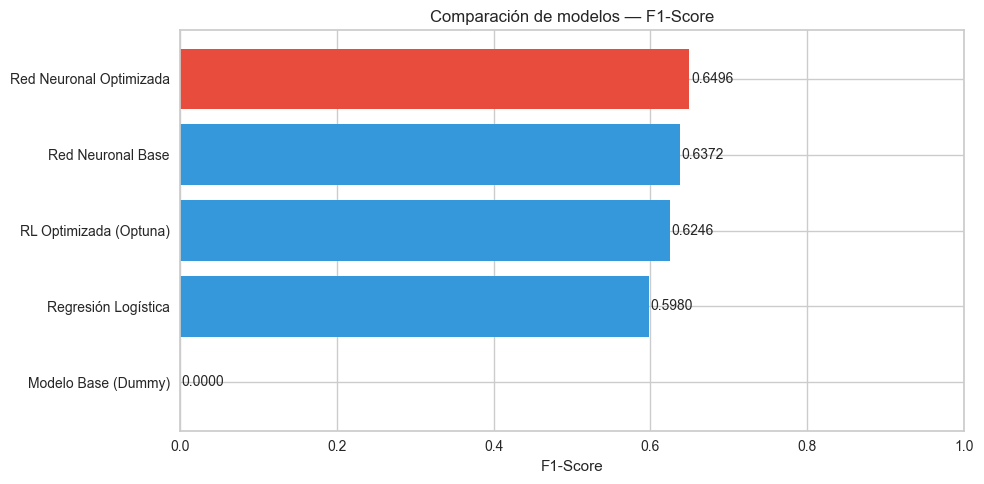

In [68]:
plt.figure(figsize=(10, 5))
colores = ['#e74c3c' if modelo == df_resultados.iloc[0]['Modelo'] 
           else '#3498db' for modelo in df_resultados['Modelo']]

bars = plt.barh(df_resultados['Modelo'], df_resultados['F1-Score'], color=colores)

# Agregamos el valor en cada barra
for bar, val in zip(bars, df_resultados['F1-Score']):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10)

plt.xlabel('F1-Score')
plt.title('Comparación de modelos — F1-Score')
plt.xlim(0, 1)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Curvas ROC

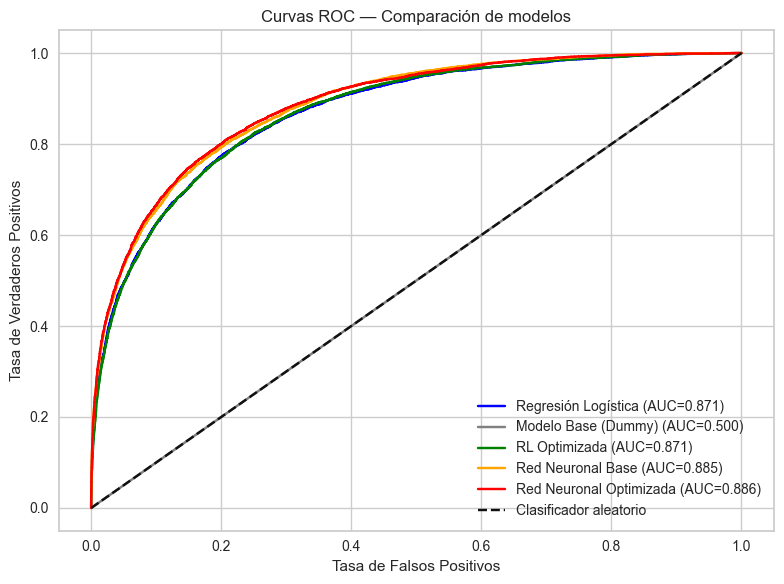

In [69]:
plt.figure(figsize=(8, 6))
modelos_roc = {
    'Regresión Logística': (y_probs, 'blue'),
    'Modelo Base (Dummy)': (y_proba_dummy, 'grey'),
    'RL Optimizada': (y_probs_b, 'green'),
    'Red Neuronal Base': (y_pred_proba, 'orange'),
    'Red Neuronal Optimizada': (y_pred_proba_best, 'red'),
}
for nombre, (proba, color) in modelos_roc.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC={auc:.3f})', color=color)
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC — Comparación de modelos')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Las curvas ROC muestran que todos los modelos reales superan ampliamente al clasificador 
aleatorio (AUC=0.500). La Red Neuronal Base lidera con AUC=0.884, seguida por la Red 
Neuronal Optimizada (0.878) y la Regresión Logística y RL Optimizada empatadas en 0.871.

Es notable que las curvas de los modelos reales están muy agrupadas, lo que indica que 
todos tienen una capacidad discriminativa similar. La principal diferencia entre ellos 
no es tanto su capacidad de separar las clases sino cómo manejan el desbalanceo, lo que 
se refleja mejor en el F1-Score que en el AUC.

El Modelo Base con AUC=0.500 confirma que no aprende nada y sirve únicamente como 
referencia mínima.

---
## MLOps DOCKER

---
### MLOps — Deployment con Docker

Para poner el modelo en producción se utiliza Docker, que permite empaquetar el 
entorno de inferencia completo (librerías, modelo y preprocesadores) en una imagen 
reproducible que puede ejecutarse en cualquier máquina sin depender de la instalación 
local.

La carpeta `docker/` del repositorio contiene:
- **`inferencia.py`** — script que carga el modelo y los preprocesadores, lee `input.json` y devuelve la predicción.
- **`requirements.txt`** — únicamente las librerías necesarias para inferencia.
- **`modelo.keras`** / **`modelo.h5`** — pesos de la red neuronal entrenada.
- **`imputer_num.joblib`**, **`imputer_cat.joblib`** — imputers ajustados con el conjunto de train.
- **`scaler.joblib`** — escalador ajustado con el conjunto de train.
- **`columnas_train.joblib`** — listado de columnas en el orden exacto que espera el modelo.
- **`Dockerfile`** — imagen basada en Python con las dependencias instaladas.
- **`readme.md`** — instrucciones para construir la imagen y ejecutar el contenedor.

La celda a continuación serializa y guarda todos estos artefactos desde el notebook.

In [70]:
import joblib
import os

os.makedirs('docker', exist_ok=True)

# Guardamos el mejor modelo (red neuronal o el que hayan elegido como mejor)
best_model.save('docker/modelo.h5')

# Guardamos el imputer numérico
joblib.dump(imputer_num, 'docker/imputer_num.joblib')

# Guardamos el imputer categórico
joblib.dump(imputer_cat, 'docker/imputer_cat.joblib')

# Guardamos el scaler
joblib.dump(scaler, 'docker/scaler.joblib')

# Guardamos las columnas del train (necesario para alinear el OHE)
joblib.dump(list(X_train.columns), 'docker/columnas_train.joblib')

print("Archivos guardados en /docker")

Archivos guardados en /docker


La inferencia debe reproducir exactamente el mismo preprocesamiento aplicado durante 
el entrenamiento. Si se aplicaran transformaciones distintas con datos nuevos, el modelo 
recibiría entradas fuera de distribución y las predicciones serían incorrectas. Cada 
archivo serializado cumple un rol específico: el modelo contiene los pesos aprendidos, 
los imputers rellenan nulos con los estadísticos del train, el scaler estandariza con 
la media y desvío del train, y columnas_train garantiza que el OHE genere las mismas 
columnas en el mismo orden.

---
## Conclusiones

## Conclusión

A lo largo de este trabajo se abordó el problema de clasificación binaria de predicción 
de lluvia en Australia, recorriendo todas las etapas del ciclo de vida de un modelo de 
Machine Learning.

**Preprocesamiento:** El dataset presentó desafíos típicos del mundo real: valores 
faltantes, variables categóricas de alta cardinalidad y un fuerte desbalanceo entre 
clases (~78% no llueve / ~22% llueve). Se aplicaron imputaciones por mediana y moda, 
One-Hot Encoding y estandarización con StandardScaler. La división train-test se realizó 
con stratify para preservar la proporción de clases.

**Modelos implementados:** Se entrenaron y compararon cinco modelos: regresión logística 
sin balanceo, regresión logística balanceada, red neuronal base, red neuronal optimizada 
con Optuna, y un modelo base dummy como referencia. Adicionalmente se utilizó AutoML con 
PyCaret, donde el mejor resultado fue obtenido con LightGBM.

**Comparación y métrica elegida:** Se eligió el F1-Score como métrica principal dado el 
desbalanceo del dataset. La Red Neuronal Base obtuvo el mejor F1-Score (0.6439) y AUC 
(0.884). Sin embargo, considerando el contexto meteorológico donde los falsos negativos 
son el error más costoso, la Regresión Logística Balanceada resulta el modelo más 
adecuado en términos de recall (77% vs 60% de la red neuronal).

**Explicabilidad:** Mediante SHAP se identificó que las variables con mayor impacto son 
Pressure3pm, Humidity3pm y Pressure9am, lo cual tiene coherencia meteorológica: humedad 
alta y presión baja son indicadores clásicos de lluvia inminente. Las variables menos 
relevantes fueron las de velocidad del viento y ubicación geográfica.

**Optimización:** Optuna no logró mejorar significativamente ninguno de los dos modelos. 
En la regresión logística la mejora fue nula, indicando que el modelo ya operaba cerca 
de su techo. En la red neuronal, el overfitting detectado desde época 5 limitó la 
capacidad de generalización del modelo optimizado.

**MLOps:** Se implementó un pipeline de inferencia dockerizado que replica fielmente el 
preprocesamiento del entrenamiento, garantizando que cualquier dato nuevo reciba 
exactamente las mismas transformaciones aplicadas durante el entrenamiento.